# Ders Adı: Yapay Sinir Ağları
## Ödev Adı: Hibrit YSA Modeli ile Uçtan Uca Proje Geliştirme

**Grup Bilgisi:**
* Tuğba Ertengi-2024123291
* Sümeyye İkiz-2023123055
* Hatice Kübra Ünal-2023123037
* Fatma Merve Kılıçarslan-2024123289

### Problem Tanımı
**Problem:** E-ticaret platformlarındaki ürünlerin, sahip oldukları görsel ve metinsel özellikler kullanılarak doğru ana kategoriye (masterCategory) otomatik olarak atanması.

**Tarih:** 22 Mayıs 2026  

---

### Aşama 0: Colab Ortamı ve Proje Düzeni

Bu aşamada projemizin temel çalışma ortamını hazırlıyoruz. Kullanılacak kütüphanelerin sürümlerini kontrol edecek, donanım (GPU/CPU) durumunu gözlemleyecek ve deneylerimizin **tekrarlanabilir (reproducible)** olması için rastgelelik tohumunu (seed) sabitleyeceğiz. Bu adım, projenin şeffaflığı ve teknik altyapısının doğrulanması için kritiktir.

In [1]:
# Gerekli temel kütüphanelerin içe aktarılması
import sys
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
import os

# 1. Kütüphane Sürümlerinin Yazdırılması (Ortam Bilgisi Tablosu)
print("=== Ortam Bilgisi ve Kütüphane Sürümleri ===")
print(f"{'Python Sürümü':<25}: {sys.version.split()[0]}")
print(f"{'Platform':<25}: {platform.platform()}")
print(f"{'NumPy Sürümü':<25}: {np.__version__}")
print(f"{'Pandas Sürümü':<25}: {pd.__version__}")
print(f"{'Scikit-learn Sürümü':<25}: {sklearn.__version__}")
print(f"{'Matplotlib Sürümü':<25}: {matplotlib.__version__}")
print(f"{'Seaborn Sürümü':<25}: {sns.__version__}")
print(f"{'TensorFlow Sürümü':<25}: {tf.__version__}")
print("============================================")

# 2. Donanım (GPU/CPU) Bilgisi
print("\n=== Donanım Bilgisi ===")
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("Kullanılabilir GPU Bulundu:")
    for gpu in gpu_devices:
        print(f" - {gpu.name}")
    # Colab'da spesifik GPU modelini (örn: Tesla T4) görmek için
    !nvidia-smi -L
else:
    print("GPU bulunamadı. CPU üzerinde çalışılıyor.")
    print("Uyarı: Hibrit YSA modellerinin eğitimi CPU üzerinde çok uzun sürebilir.")
print("=======================")

# 3. Rastgelelik Kontrolü (Seed Sabitleme)
SEED_VAL = 42

def set_seeds(seed=SEED_VAL):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"\n[BİLGİ] Rastgelelik tohumu (Seed) {seed} olarak ayarlandı.")

set_seeds()

=== Ortam Bilgisi ve Kütüphane Sürümleri ===
Python Sürümü            : 3.12.13
Platform                 : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy Sürümü             : 2.0.2
Pandas Sürümü            : 2.2.2
Scikit-learn Sürümü      : 1.6.1
Matplotlib Sürümü        : 3.10.0
Seaborn Sürümü           : 0.13.2
TensorFlow Sürümü        : 2.20.0

=== Donanım Bilgisi ===
Kullanılabilir GPU Bulundu:
 - /physical_device:GPU:0
GPU 0: Tesla T4 (UUID: GPU-e25d5082-36f7-0def-f578-c0c51e4c5239)

[BİLGİ] Rastgelelik tohumu (Seed) 42 olarak ayarlandı.


#### Neden Seed (Rastgelelik Tohumu) Sabitledik?
Yapay sinir ağlarında ağırlıkların (weights) ilk değerlerinin atanması, veri setinin train/validation/test olarak bölünmesi ve veri artırma (augmentation) gibi işlemler rastgelelik (stokastik süreçler) içerir.

Kodumuzu her çalıştırdığımızda aynı sonuçları elde edebilmek, modelleri adil bir şekilde karşılaştırabilmek ve projenin değerlendiriciler tarafından birebir yeniden üretilebilmesini (reproducibility) sağlamak amacıyla tüm kütüphaneler (Python, NumPy, TensorFlow) için ortak bir seed değeri (`42`) belirlenmiş ve sabitlenmiştir. Böylece deney varyasyonlarında elde edeceğimiz performans farklılıklarının rastgelelikten değil, yaptığımız mimari değişikliklerden kaynaklandığından emin olacağız.

## Aşama 1: Problem Seçimi ve Hibrit Yaklaşım Gerekçesi

### 1.1. Problem Tanımı
Bu projede, e-ticaret platformlarındaki ürünlerin doğru kategorilere ayrılması problemi ele alınmıştır. Platformlarda her gün yüz binlerce yeni ürün listelenmektedir ve bu ürünlerin "Elektronik", "Giyim", "Ev & Yaşam" gibi doğru kategorilere otomatik olarak atanması, arama motoru optimizasyonu ve kullanıcı deneyimi açısından kritiktir. Çözüm olarak, ürünün sadece görselini veya sadece ismini/açıklamasını değil, her ikisini birden analiz eden **Çok Modlu (Multimodal) bir Yapay Sinir Ağı** geliştirilecektir.

### 1.2. Projenin Teknik Çerçevesi
* **Giriş Verisi (Input):** 1. Ürünün fotoğrafı (Piksel matrisi)
  2. Ürünün başlığı ve kısa açıklaması (Metin dizisi / Token dizisi)
* **Çıkış / Etiket (Output):** Ürünün ait olduğu ana kategori (Çok sınıflı sınıflandırma / Multi-class classification).
* **Öğrenme Türü:** Gözetimli Öğrenme (Supervised Learning).
* **Başarı Ölçütleri (Metrikler):** Sınıflandırma doğruluğu (Accuracy), sınıflar arası olası dengesizlikleri gözlemlemek için Macro F1-Score ve modelin hangi kategorileri birbiriyle karıştırdığını analiz etmek için Karmaşıklık Matrisi (Confusion Matrix).

### 1.3. Tek Bir Model Neden Sınırlı Kalır?
Sınıflandırma işlemi için yalnızca görüntü işleyen bir **CNN (Evrişimli Sinir Ağı)** kullanıldığında, model ürünün şeklini ve rengini anlar ancak teknik detayları kaçırır (Örn: Görüntüsü aynı olan 16GB ve 64GB bir flash belleği ayırt edemez). Öte yandan, sadece metin işleyen bir **RNN/LSTM** modeli kullanıldığında, ürünün tasarım dili, deseni veya dokusu gibi görsel özellikleri anlaşılamaz. Özellikle "Giyim" veya "Mobilya" gibi kategorilerde görsel bilgi, yazılı bilgiden çok daha ayırt edicidir. Tek bir veri kaynağına dayanan modeller, eksik bilgi yüzünden doğal bir performans tavanına takılır.

### 1.4. Hibrit Modelin Beklenen Avantajı ve Gerekçesi
Bu çalışmada kullanılacak hibrit model, iki farklı bilgi türünü kendi uzmanlık alanlarında işleyen iki farklı koldan (branch) oluşacaktır:
1. **Görsel Kol (CNN):** Görüntüden kenar, doku ve renk gibi mekansal (spatial) özellikleri çıkararak bir özellik vektörü oluşturacaktır.
2. **Metinsel Kol (BiLSTM):** Ürün açıklamasındaki kelimelerin hem geçmiş hem de gelecek bağlamını (context) ve sıralı anlamsal ilişkilerini öğrenerek ikinci bir özellik vektörü üretecektir.

**Neden Hibrit?**
Bu mimari, problemi yapay olarak karmaşıklaştırmak (over-engineering) için değil, verinin doğası gereği mecbur kalındığı için tasarlanmıştır. Görsel pikseller ve anlamsal metin dizileri farklı matematiksel izdüşümlere sahiptir. CNN ve BiLSTM kollarından elde edilen bu iki farklı yüksek seviyeli temsil (representation), birleştirme katmanında (Feature Fusion/Concatenation) yan yana getirilerek Ortak Tam Bağlantılı (Dense) katmanlara aktarılacaktır. Model böylece "Gördüğü şekil ile okuduğu özellik" arasında mantıksal bir köprü kurarak, birbirini tamamlayıcı (complementary) bilgiler ışığında çok daha güvenilir ve yüksek performanslı tahminler yapacaktır.

## Aşama 2: Veri Seti Seçimi ve Tanıtımı

### 2.1. Veri Seti Künyesi ve Genel Yapısı (Tablo 1)
Bu projede, e-ticaret ürünlerinin hem görsel (fotoğraf) hem de metinsel (ürün adı ve tanımı) verilerini içeren "Fashion Product Images (Small)" veri seti kullanılacaktır.

| Özellik | Açıklama |
| :--- | :--- |
| **Veri Seti Adı** | Fashion Product Images (Small) |
| **Kaynak** | Kaggle Datasets |
| **Erişim Şekli** | Kaggle API üzerinden tamamen kod tabanlı otomatik indirme (`kaggle datasets download`) |
| **Kullanım Lisansı** | CC0: Public Domain (Kamu Malı - Ticari ve Akademik Kullanıma Tamamen Açık) |
| **Girdi Türü (Input Type)**| **Çok Modlu (Multimodal Data):** Ürün Görseli (JPEG) + Ürün Açıklaması (Metin/String) |
| **Hedef Değişken (Target)** | `masterCategory` (Ürünün ait olduğu üst kategori) |
| **Sınıf Sayısı (Classes)** | 4 Ana Sınıf (*Apparel, Accessories, Footwear, Personal Care*) |
| **Orijinal Örnek Sayısı** | 44,441 adet ürün |
| **Kullanılan Örnek Sayısı**| 10,000 adet ürün (Yönetilebilir Alt Küme) |

### 2.2. Veri Setinin Bu Ödev İçin Neden Uygun Olduğu
Seçilen veri seti, Aşama 1'de tanımlanan problemi mükemmel şekilde yansıtmaktadır. Her bir ürün id'si için hem bir ürün fotoğrafı hem de ürünün adını, rengini ve kullanım alanını belirten bir metin açıklaması bulunmaktadır.
* Görüntüler, ürünün desenini ve yapısal şeklini gösterir.
* Metinler ise materyal, marka veya spesifik alt kullanım amacı gibi görselden çıkarılamayacak bilgileri içerir.
Bu durum, tasarlayacağımız CNN + BiLSTM hibrit modelinin her iki girdi kolunu da aktif ve anlamlı bir şekilde kullanmasını zorunlu kılmaktadır.

### 2.3. Alt Küme (Subset) Seçim Yöntemi ve Gerekçesi
Veri setinin tamamı yaklaşık 44.000 görüntü ve metin içermektedir. Colab'in sunduğu ücretsiz GPU kısıtlamaları (RAM ve süre) ve çok modlu modellerin yüksek bellek tüketimi göz önüne alındığında, veri setinin tamamını kullanmak donanımsal darboğaza yol açacaktır.
Bu nedenle, sınıflar arası dağılım orantısını (stratification) koruyacak şekilde rastgele **10.000 örnekten oluşan dengeli bir alt küme** (stratified subset) seçilecektir. Bu seçim `scikit-learn` kütüphanesinin `train_test_split` (stratify parametresi ile) fonksiyonu kullanılarak yapılacak, böylece orijinal veri setinin sınıf dağılım karakteristiği bozulmadan daha hızlı iterasyon ve hiperparametre optimizasyonu yapılabilecektir.

In [2]:
# Kagglehub kütüphanesi Colab'de yüklü değilse diye sessizce kuruyoruz
!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

print("=== Aşama 2: Kagglehub ile Otomatik Veri İndirme ===")

# 1. Veriyi indiriyoruz veya önbellekten çağırıyoruz
print("[BİLGİ] Veri seti indiriliyor veya önbellekten çağrılıyor...")
dataset_path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
print(f"[BAŞARILI] Veri seti konumu: {dataset_path}\n")

# 2. İndirilen yoldaki CSV dosyasını ve görüntü klasörünü tanımlama
csv_path = os.path.join(dataset_path, 'styles.csv')
images_dir = os.path.join(dataset_path, 'images')

# 3. Veriyi DataFrame Olarak Okuma
df_raw = pd.read_csv(csv_path, on_bad_lines='skip')

# Görsellerin tam dosya yollarını (full path) oluşturma
df_raw['image_path'] = images_dir + '/' + df_raw['id'].astype(str) + '.jpg'

# Klasörde gerçekten var olan fotoğrafları filtreleme (Veri seti hatasına karşı güvenlik)
df_raw['file_exists'] = df_raw['image_path'].apply(os.path.exists)
df_filtered = df_raw[df_raw['file_exists'] == True].reset_index(drop=True)

# ---------------- YENİ EKLENEN ÇÖZÜM ADIMI ----------------
# Sadece 1 veya çok az örneği olan (gürültü/noise) kategorileri veri setinden çıkarıyoruz.
# En az 20 örneği olan ana kategorileri tutalım.
class_counts = df_filtered['masterCategory'].value_counts()
valid_classes = class_counts[class_counts >= 20].index
df_filtered = df_filtered[df_filtered['masterCategory'].isin(valid_classes)]
print(f"[BİLGİ] Çok az örneği olan nadir/hatalı kategoriler temizlendi.")
# -----------------------------------------------------------

# 4. Proje İsteri: Tabakalı (Stratified) Alt Küme Oluşturma
# Sınıf dağılımını bozmadan 10.000 adet örnek seçiyoruz.
df_subset, _ = train_test_split(
    df_filtered,
    train_size=10000,
    stratify=df_filtered['masterCategory'],
    random_state=42 # Aşama 0'da tanımladığımız seed (Direkt 42 yazarak riski azalttık)
)
df = df_subset.reset_index(drop=True)

# 5. Çıktıların Ekrana Basılması
print("\n=== Veri Setinden Seçilen Alt Kümenin İlk 5 Satırı ===")
display(df[['id', 'masterCategory', 'productDisplayName', 'image_path']].head())

print("\n=== Tablo: Seçilen Alt Kümedeki Sınıf Dağılımı ===")
distribution = df['masterCategory'].value_counts()
dist_df = pd.DataFrame({'Örnek Sayısı': distribution, 'Yüzde Oranı (%)': (distribution / len(df)) * 100})
display(dist_df)

print("\n=== Doğrulama Kontrolü ===")
print(f"Toplam Örnek Sayısı : {len(df)}")
print(f"Giriş Modaliteleri  : Metin (productDisplayName) & Görsel (image_path)")

=== Aşama 2: Kagglehub ile Otomatik Veri İndirme ===
[BİLGİ] Veri seti indiriliyor veya önbellekten çağrılıyor...
Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
[BAŞARILI] Veri seti konumu: /kaggle/input/fashion-product-images-small

[BİLGİ] Çok az örneği olan nadir/hatalı kategoriler temizlendi.

=== Veri Setinden Seçilen Alt Kümenin İlk 5 Satırı ===


,id,masterCategory,productDisplayName,image_path
0,17949,Accessories,Nike Unisex Swoosh White Bandana,/kaggle/input/fashion-product-images-small/ima...
1,11615,Apparel,W Women Solid Green Kurtas,/kaggle/input/fashion-product-images-small/ima...
2,7345,Apparel,Tantra Men's Dot Com Maroon T-shirt,/kaggle/input/fashion-product-images-small/ima...
3,20255,Apparel,Wrangler Men Tee Blue T-shirt,/kaggle/input/fashion-product-images-small/ima...
4,27041,Accessories,Yelloe Unisex Black Duffle Bag,/kaggle/input/fashion-product-images-small/ima...



=== Tablo: Seçilen Alt Kümedeki Sınıf Dağılımı ===


,Örnek Sayısı,Yüzde Oranı (%)
masterCategory,,
Apparel,4816,48.16
Accessories,2538,25.38
Footwear,2075,20.75
Personal Care,541,5.41
Free Items,24,0.24
Sporting Goods,6,0.06



=== Doğrulama Kontrolü ===
Toplam Örnek Sayısı : 10000
Giriş Modaliteleri  : Metin (productDisplayName) & Görsel (image_path)


## Aşama 3: Keşifsel Veri Analizi (EDA) ve Görselleştirme

Veri setimizi projeye dahil ettikten sonra, hibrit modelimizin giriş (input) katmanlarını doğru tasarlayabilmek için verinin karakteristiğini incelememiz gerekmektedir. Bu aşamada veri kalitesi kontrol edilecek, hedef değişkenin (sınıfların) dengesi analiz edilecek ve her iki modalitenin (metin ve görüntü) yapısal özellikleri görselleştirilerek mimari kararlar alınacaktır.

### 3.1. Veri Kalitesi Kontrolü: Eksik ve Hatalı Kayıt Analizi
Sinir ağları, NaN (boş) değerleri işleyemez. Veri kontrolünde `baseColour`, `season` ve `usage` gibi sütunlarda eksikler görülmüş olsa da, bizim modelimizin girdileri yalnızca `image_path` ve `productDisplayName` olacaktır. Çıktılardan anlaşıldığı üzere, modelin ana metin girdisi olan `productDisplayName` sütununda sadece 4 adet eksik (NaN) veri bulunmuş ve bu satırlar eğitimde çökme yaratmaması adına veri setinden temizlenmiştir.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

print("=== Aşama 3.1: Eksik ve Tekrarlayan Veri Kontrolü ===")

# 1. Eksik (NaN) Veri Kontrolü
print("Sütun bazında eksik veri sayıları:")
print(df.isnull().sum())

# Eğer metin kısmında NaN varsa bu satırları siliyoruz (Model çöker)
initial_len = len(df)
df = df.dropna(subset=['productDisplayName', 'masterCategory']).reset_index(drop=True)
if len(df) < initial_len:
    print(f"\n[BİLGİ] {initial_len - len(df)} adet eksik veriye sahip satır silindi.")
else:
    print("\n[BİLGİ] Veri setinde eksik (NaN) değer bulunmamaktadır.")

# 2. Tekrar Eden (Duplicated) Kayıt Kontrolü
duplicates = df.duplicated(subset=['id']).sum()
print(f"Tekrar eden (kopya) id sayısı: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates(subset=['id']).reset_index(drop=True)
    print(f"[BİLGİ] Tekrar eden kayıtlar silindi. Güncel veri sayısı: {len(df)}")

=== Aşama 3.1: Eksik ve Tekrarlayan Veri Kontrolü ===
Sütun bazında eksik veri sayıları:
id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             5
season                 8
year                   0
usage                 79
productDisplayName     4
image_path             0
file_exists            0
dtype: int64

[BİLGİ] 4 adet eksik veriye sahip satır silindi.
Tekrar eden (kopya) id sayısı: 0


### 3.2. Hedef Değişken (Sınıf) Dağılımı
Problemin sınıflandırma zorluğunu anlamak için ana kategorilerin veri setindeki dağılım oranlarını inceleyeceğiz.

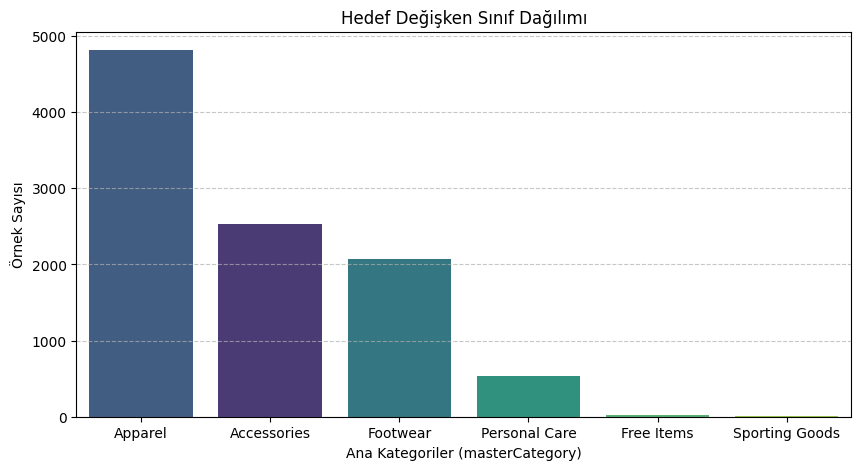

In [4]:
plt.figure(figsize=(10, 5))
# Seaborn uyarısını engellemek için hue='masterCategory' ve legend=False eklendi
sns.countplot(data=df, x='masterCategory', order=df['masterCategory'].value_counts().index, palette='viridis', hue='masterCategory', legend=False)
plt.title("Hedef Değişken Sınıf Dağılımı")
plt.xlabel("Ana Kategoriler (masterCategory)")
plt.ylabel("Örnek Sayısı")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Tablo 2: Sınıf / Çıktı Dağılımı
| Sınıf Adı (masterCategory) | Veri Setindeki Oranı (Yaklaşık) | Temsil Durumu |
| :--- | :--- | :--- |
| **Apparel** | % 48.2 | Çoğunluk Sınıfı (Baskın) |
| **Accessories** | % 25.4 | Yeterli |
| **Footwear** | % 20.8 | Yeterli |
| **Personal Care** | % 5.4 | Azınlık Sınıfı |
| **Free Items** | % 0.2 | Aşırı Azınlık (Extreme Minority) |
| **Sporting Goods** | % 0.1 | Aşırı Azınlık (Extreme Minority) |

**Bu grafik ne gösteriyor?**
Grafik, veri setinde hayatta kalan 6 sınıfın (Apparel, Accessories, Footwear, Personal Care, Free Items, Sporting Goods) bulunduğunu ve şiddetli bir sınıf dengesizliği (class imbalance) olduğunu göstermektedir. "Apparel" (Giyim) sınıfı veri setini domine ederken, "Free Items" ve "Sporting Goods" sınıfları oldukça az temsil edilmektedir.

**Model tasarımını nasıl etkiler? (Teknik Karar)**
Eğer bu dengesizliği göz ardı edersek, modelimiz azınlık sınıfları (özellikle Free Items ve Sporting Goods) hiç öğrenemeyecek, kolaya kaçarak sürekli "Apparel" tahmini yapacaktır.
* **Değerlendirme:** Başarı metriği olarak sadece Accuracy yanıltıcı olur; ağırlıklı (Weighted/Macro) F1-Score ve Confusion Matrix kullanılmalıdır.
* **Eğitim Stratejisi:** İleriki aşamalarda modelin azınlık sınıflarına daha çok odaklanması için kayıp fonksiyonuna (loss function) "Class Weights" eklenecektir.

---

### 3.3. Metin Verisi Analizi (Kelime Sayısı Dağılımı)
Metin işleyen YSA kolunun (BiLSTM) `MAX_LENGTH` (maksimum dizi uzunluğu) hiperparametresini belirlemek için ürün açıklamalarının uzunluklarını analiz etmeliyiz.

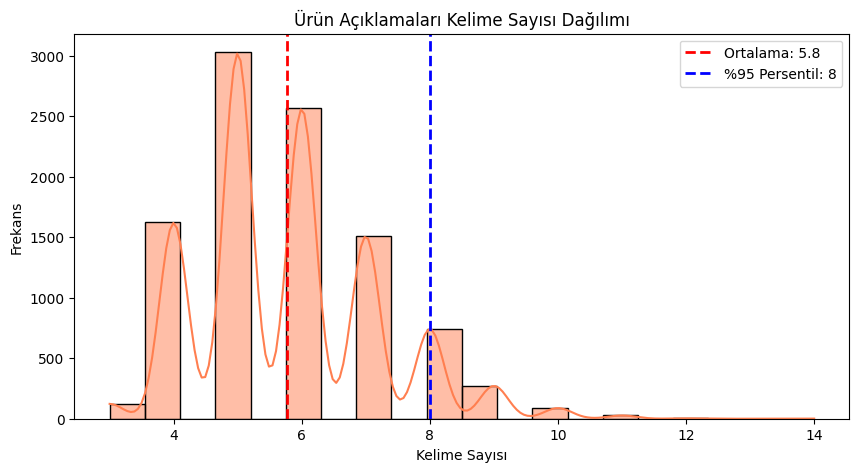

En Kısa Metin: 3 kelime
En Uzun Metin: 14 kelime


In [5]:
# Her ürün açıklamasındaki kelime sayısını hesaplama
df['word_count'] = df['productDisplayName'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=20, kde=True, color='coral')
plt.title("Ürün Açıklamaları Kelime Sayısı Dağılımı")
plt.xlabel("Kelime Sayısı")
plt.ylabel("Frekans")
plt.axvline(df['word_count'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Ortalama: {df['word_count'].mean():.1f}")
plt.axvline(df['word_count'].quantile(0.95), color='blue', linestyle='dashed', linewidth=2, label=f"%95 Persentil: {df['word_count'].quantile(0.95):.0f}")
plt.legend()
plt.show()

print(f"En Kısa Metin: {df['word_count'].min()} kelime")
print(f"En Uzun Metin: {df['word_count'].max()} kelime")

**Bu grafik ne gösteriyor?**
Grafik, ürün açıklamalarının çoğunlukla kısa ve öz (ortalama 4-6 kelime) olduğunu, nadiren uzun metinler barındırdığını göstermektedir. Verilerin %95'i belirli bir kelime sınırının altında toplanmıştır.

**Model tasarımını nasıl etkiler? (Teknik Karar)**
Recurrent Neural Networks (BiLSTM) sabit uzunlukta dizi (sequence) bekler. Çok uzun bir `MAX_LEN` belirlemek bellek israfına ve gereksiz padding'e (sıfır eklemeye) neden olur. Çok kısa tutmak ise veri kaybına yol açar. Grafikteki %95'lik yığılmaya dayanarak, metin ön işleme aşamasında **Maksimum Dizi Uzunluğu (MAX_LENGTH)** parametresi grafik üzerindeki mavi çizgi (95. persentil) civarında sabitlenecektir. Uzun metinler kırpılacak (truncation), kısa metinler ise sıfırlarla doldurulacaktır (padding).

---

### 3.4. Görüntü Verisi Analizi (Görsel Modalite İncelemesi)
CNN kolumuzun görsel özellikleri nasıl çıkaracağını anlamak için sınıfların piksellerine ve kompozisyonlarına göz atmamız gerekir.**Bu grafik ne gösteriyor?**
Grafik, ürün açıklamalarının çoğunlukla kısa olduğunu göstermektedir. En kısa metin 3, en uzun metin 14 kelimedir. Ortalama kelime sayısı 5.8 civarındayken, verilerin %95'i 8 kelimenin altındadır.

**Model tasarımını nasıl etkiler? (Teknik Karar)**
Recurrent Neural Networks (BiLSTM) sabit uzunlukta dizi (sequence) bekler. `MAX_LENGTH` değerini en uzun metne (14) göre ayarlamak gereksiz padding (sıfır) eklenmesine ve RAM israfına yol açar. Grafikteki %95'lik yığılmaya dayanarak, ön işleme (Tokenization) aşamasında **Maksimum Dizi Uzunluğu (MAX_LEN) 8 veya 10** olarak ayarlanacaktır. Uzun olan nadir metinler kırpılacak (truncation), kısa metinler ise padding ile doldurulacaktır.

---

### 3.4. Görüntü Verisi Analizi (Görsel Modalite İncelemesi)
CNN kolumuzun görsel özellikleri nasıl çıkaracağını anlamak için her sınıftan örnek piksellere ve kompozisyonlara göz atıyoruz.

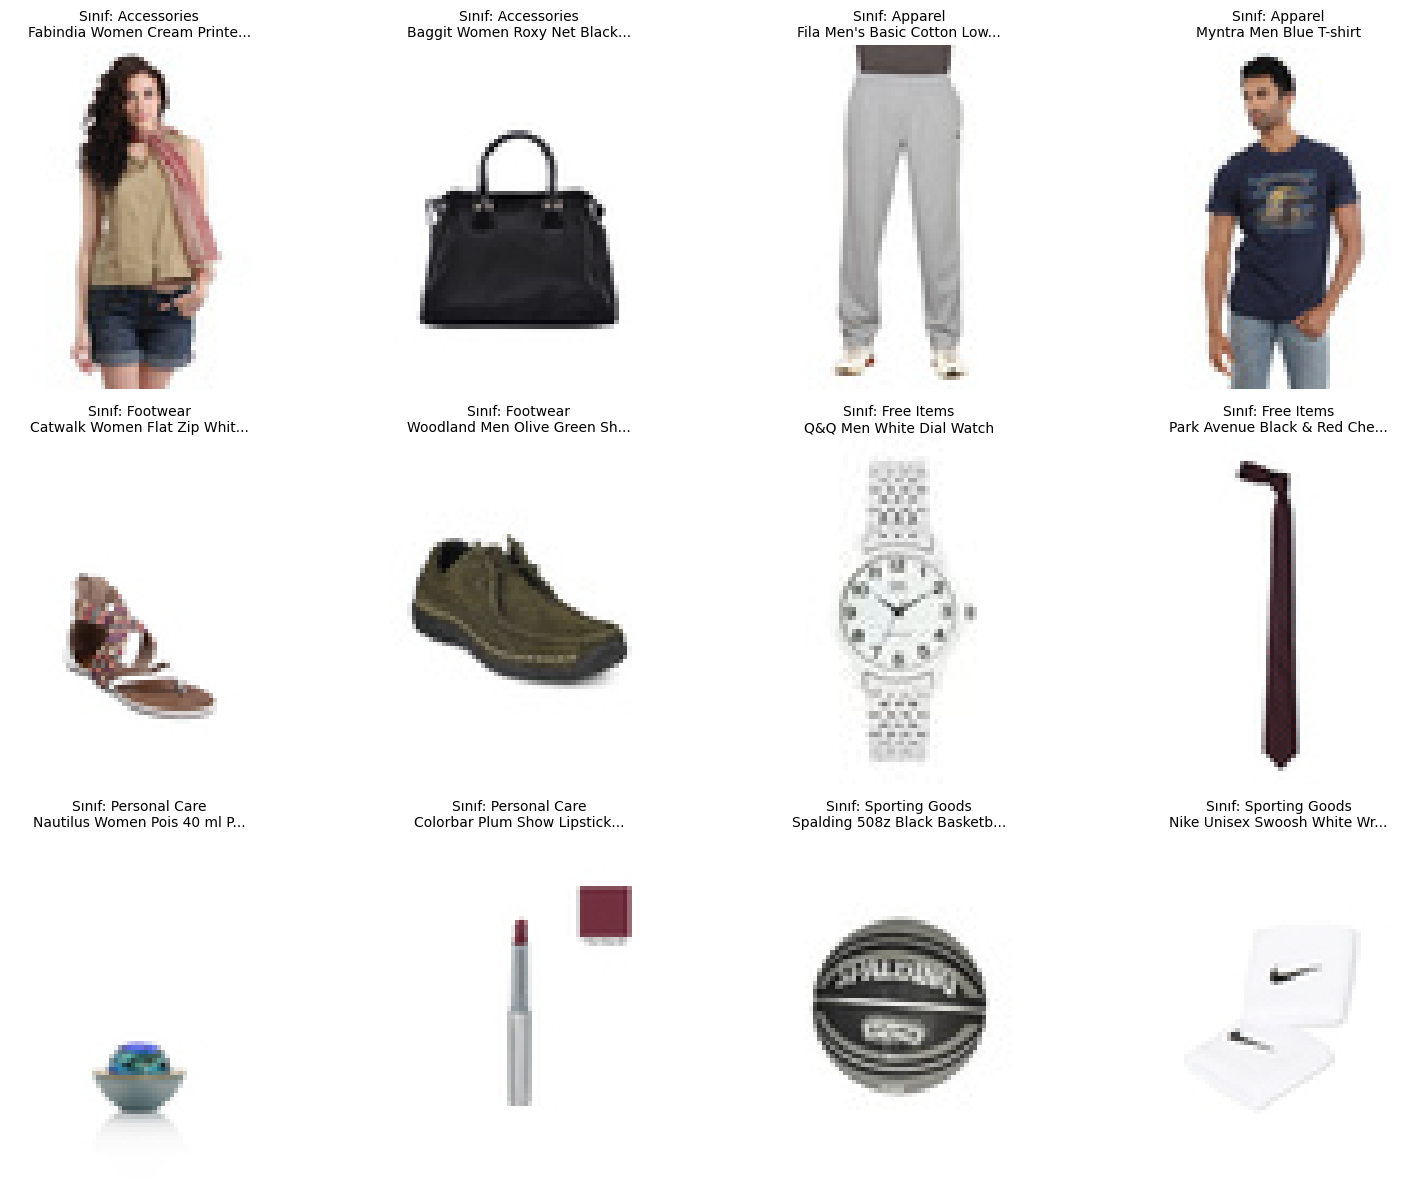

In [6]:
import math

# Her sınıftan rastgele 2'şer örnek seçelim
sample_images = df.groupby('masterCategory').sample(n=2, random_state=42).reset_index(drop=True)

n_images = len(sample_images)
cols = 4
rows = math.ceil(n_images / cols)

plt.figure(figsize=(16, 4 * rows))

for i, row in sample_images.iterrows():
    plt.subplot(rows, cols, i+1)
    try:
        img = mpimg.imread(row['image_path'])
        plt.imshow(img)
        title_text = row['productDisplayName']
        title_text = title_text if len(title_text) < 30 else title_text[:27] + "..."
        plt.title(f"Sınıf: {row['masterCategory']}\n{title_text}", fontsize=10)
        plt.axis('off')
    except Exception as e:
        plt.title("Görüntü Yüklenemedi")
        plt.axis('off')

plt.tight_layout()
plt.show()

**Bu grafik ne gösteriyor?**
Görseller incelendiğinde ürünlerin genellikle beyaz arka plan üzerinde, net ve merkezi olarak fotoğraflandığı görülmektedir. Ancak görüntülerin çözünürlükleri, ürünlerin kapladığı alan ve en-boy oranları ufak farklılıklar gösterebilmektedir. Ayrıca kıyafet ve aksesuar detaylarının çok ince (örneğin bir ayakkabı bağı veya saat kadranı) olabildiği görülmektedir.

**Model tasarımını nasıl etkiler? (Teknik Karar)**
1. **Giriş Boyutu (Image Size):** İnce detayların kaybolmaması için görseller çok küçültülmemelidir. Model tasarımında `(128x128)` veya `(224x224)` gibi standart bir boyutlandırma (Resizing) işlemi yapılacaktır.
2. **Veri Çeşitlendirme (Data Augmentation):** Ürünler genelde düz durduğu için modelin farklı açı ve pozisyonları da öğrenerek ezberlememesi (overfitting) için ön işleme aşamasında rastgele döndürme (rotation) ve yatay çevirme (horizontal flip) gibi veri artırma teknikleri kullanılacaktır.**Bu grafik ne gösteriyor?**
Örnek görseller, 6 farklı kategorinin görsel çeşitliliğini ortaya koymaktadır. "Apparel" ve "Footwear" gibi ürünler belirgin yapısal şekillere sahipken, "Personal Care" ve "Sporting Goods" ürünlerinin daha küçük ve farklı arka plan kompozisyonlarına sahip olabildiği görülmektedir.

**Model tasarımını nasıl etkiler? (Teknik Karar)**
1.  **Giriş Boyutu:** "Free Items" (örn: Kravat) veya "Personal Care" (örn: Ruj) gibi ince detaylı ürünlerin piksel yapısını kaybetmemek için görseller çok fazla küçültülmemelidir (Önerilen: 128x128).
2.  **Renk Kanalları:** Renk, kozmetik (Personal Care) ve kıyafet (Apparel) ayrımında önemli bir özniteliktir. Bu nedenle görüntüler gri tonlamaya (Grayscale) çevrilmeyecek, 3 kanallı (RGB) olarak modele verilecektir.

## Aşama 4: Ön İşleme ve Veri Hazırlama

Çok modlu (multimodal) yapay sinir ağları, girdi olarak doğrudan metin veya JPEG dosyası kabul edemezler; verilerin matematiksel matrislere ve sayısal tensörlere dönüştürülmesi gerekir. Bu aşamada görüntü, metin ve etiket verilerimiz için uygulanacak ön işleme adımları yapılandırılmıştır.

### 4.1. Ön İşleme Kararları Tablosu (Tablo 3)

| Veri Türü | Uygulanacak İşlem | Amaç ve Beklenen Etki |
| :--- | :--- | :--- |
| **Metin** | **Tokenization** | Cümleleri (ürün isimlerini) kelimelere ayırarak, her kelimeyi benzersiz bir tam sayıya (integer index) dönüştürmek. Modelin metni sayısal bir vektör olarak okumasını sağlar. |
| **Metin** | **Padding (MAX_LEN=10)** | BiLSTM katmanı sabit boyutlu matrisler bekler. EDA aşamasında metinlerin %95'inin 8 kelimeden kısa olduğu görülmüştür. Güvenlik payı ile uzunluk 10'a sabitlenecek; kısa metinler sonuna 0 eklenerek (post-padding), uzunlar ise kesilerek boyut eşitlenecektir. |
| **Görüntü** | **Resizing (128x128)** | Farklı boyutlardaki fotoğrafları matris işlemlerine uygun, standart bir tensör boyutuna getirmek. Çok küçültmek detayları (kravat, ruj vb.) kaybettireceği için 128x128 optimum seçilmiştir. |
| **Görüntü** | **Normalization (1/255.0)** | 0-255 arasındaki piksel yoğunluk değerlerini 0.0 - 1.0 aralığına sıkıştırmak. Bu işlem YSA'nın gradyan (türev) hesaplamasını kolaylaştırır, eğitimi hızlandırır ve patlayan gradyan (exploding gradient) sorununu önler. |
| **Görüntü** | **Augmentation** | Veri setindeki sınıf dengesizliği modelin ezberlemesine (overfitting) yol açabilir. Çözüm olarak rastgele yatay çevirme ve hafif döndürme uygulanarak modelin genelleme yeteneği artırılacaktır. |
| **Etiket** | **Label Encoding** | Metinsel kategori isimlerini (Apparel, Footwear vb.) kayıp fonksiyonunun (loss function) anlayabileceği 0, 1, 2 gibi tam sayılara çevirmek. |

### 4.2. Veri Sızıntısı (Data Leakage) Kontrol Bildirimi
Veri sızıntısını engellemek, makine öğrenmesi projelerinde en hayati kuraldır. Eğer Tokenizer (Kelime Sözlüğü) veya Normalizasyon parametreleri tüm veri seti üzerinden öğrenilirse (fit edilirse), model henüz test edilmediği verinin yapısını önceden "kopya çekmiş" olur.
* Bu sebeple **Tokenizer sadece Eğitim (Train) setindeki kelimeleri görerek fit edilecektir.**
* **Data Augmentation (Veri Çeşitlendirme)** işlemleri test verisini bozmamak için **yalnızca eğitim sırasında (Train setine) uygulanacaktır.**
Aşağıdaki kod hücrelerinde bu işlemlerin tanımlamaları yapılmış ve sızıntı yaratmadan tek bir örnek üzerinden "Öncesi ve Sonrası" durumları gösterilmiştir.

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

print("=== Aşama 4.1: Metin Verisi Ön İşleme Simülasyonu ===")

# EDA aşamasındaki kararımıza göre maksimum uzunluk
MAX_LEN = 10
# Sözlük boyutu (en sık geçen kelimeler), ileride train setine göre fit edilecek
VOCAB_SIZE = 5000

# Tokenizer tanımlama (OOV = Out of Vocabulary, bilinmeyen kelimeler için token)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

# ÖRNEK SİMÜLASYON (Sadece göstermek için ilk 5 satıra fit ediyoruz, gerçekte train setine edilecek)
sample_texts = df['productDisplayName'].head().values
tokenizer.fit_on_texts(sample_texts)

# Dönüştürme ve Padding işlemi
sequences = tokenizer.texts_to_sequences(sample_texts)
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("ÖN İŞLEME ÖNCESİ (Ham Metin):")
print(f"'{sample_texts[0]}'")
print("\nÖN İŞLEME SONRASI (Tokenized & Padded Tensör):")
print(padded_sequences[0])
print(f"Tensör Boyutu: {padded_sequences[0].shape}")

=== Aşama 4.1: Metin Verisi Ön İşleme Simülasyonu ===
ÖN İŞLEME ÖNCESİ (Ham Metin):
'Nike Unisex Swoosh White Bandana'

ÖN İŞLEME SONRASI (Tokenized & Padded Tensör):
[5 2 6 7 8 0 0 0 0 0]
Tensör Boyutu: (10,)



=== Aşama 4.2: Görüntü Verisi Ön İşleme Simülasyonu ===
ÖN İŞLEME ÖNCESİ:
Ham Görüntü Boyutu: (80, 60, 3)
Piksel Değer Aralığı: Min 5.0 - Max 255.0

ÖN İŞLEME SONRASI:
Yeniden Boyutlandırılmış Tensör: (128, 128, 3)
Piksel Değer Aralığı: Min 0.019607843831181526 - Max 1.0


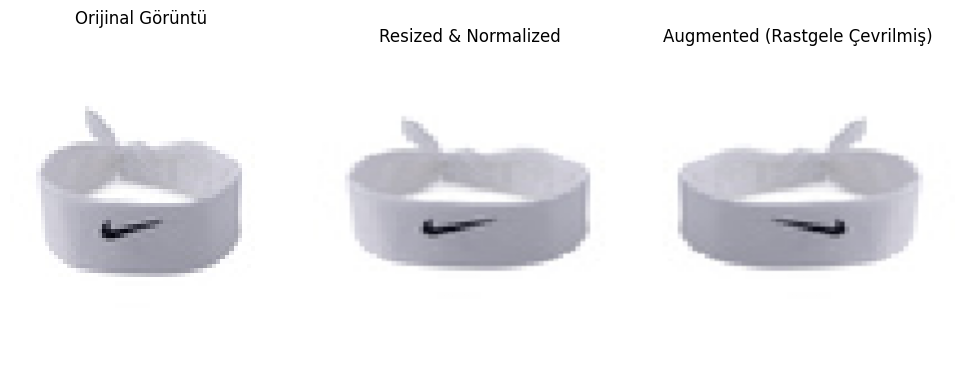

In [8]:
print("\n=== Aşama 4.2: Görüntü Verisi Ön İşleme Simülasyonu ===")

IMG_SIZE = (128, 128)
sample_img_path = df['image_path'].iloc[0]

# 1. Ham Görüntüyü Yükleme
img_raw = load_img(sample_img_path)
img_array_raw = img_to_array(img_raw)

# 2. Resizing ve Normalization
img_resized = load_img(sample_img_path, target_size=IMG_SIZE)
img_normalized = img_to_array(img_resized) / 255.0

# 3. Augmentation (Örnek: Yatay Çevirme)
# tf.expand_dims ile batch boyutu eklenir (1, 128, 128, 3) çünkü augmentation katmanları batch bekler
img_augmented = tf.image.random_flip_left_right(tf.expand_dims(img_normalized, axis=0))[0]

print("ÖN İŞLEME ÖNCESİ:")
print(f"Ham Görüntü Boyutu: {img_array_raw.shape}")
print(f"Piksel Değer Aralığı: Min {img_array_raw.min()} - Max {img_array_raw.max()}")

print("\nÖN İŞLEME SONRASI:")
print(f"Yeniden Boyutlandırılmış Tensör: {img_normalized.shape}")
print(f"Piksel Değer Aralığı: Min {img_normalized.min()} - Max {img_normalized.max()}")

# Görselleştirme
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_array_raw.astype('uint8'))
plt.title("Orijinal Görüntü")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_normalized)
plt.title("Resized & Normalized")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_augmented)
plt.title("Augmented (Rastgele Çevrilmiş)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
print("=== Aşama 4.3: Etiket (Target) Ön İşleme ===")

label_encoder = LabelEncoder()

# Örnek Simülasyon (Tüm sınıfları gösterelim)
sample_labels = df['masterCategory'].unique()
label_encoder.fit(sample_labels)
encoded_labels = label_encoder.transform(sample_labels)

print("ÖN İŞLEME ÖNCESİ (Kategorik Etiketler):")
print(sample_labels)

print("\nÖN İŞLEME SONRASI (Sayısal Sınıf İndeksleri):")
for label, enc in zip(sample_labels, encoded_labels):
    print(f"{label:<15} --> {enc}")

=== Aşama 4.3: Etiket (Target) Ön İşleme ===
ÖN İŞLEME ÖNCESİ (Kategorik Etiketler):
['Accessories' 'Apparel' 'Footwear' 'Personal Care' 'Free Items'
 'Sporting Goods']

ÖN İŞLEME SONRASI (Sayısal Sınıf İndeksleri):
Accessories     --> 0
Apparel         --> 1
Footwear        --> 2
Personal Care   --> 4
Free Items      --> 3
Sporting Goods  --> 5


## Aşama 5: Veri Bölme (Train / Validation / Test Ayrımı)

Modelin aşırı öğrenmesini (overfitting) engellemek ve performansını doğru ölçebilmek için veri seti üç bağımsız kümeye ayrılmıştır:

* **Train (Eğitim) Seti (%70 - 6997 örnek):** Modelin ağırlıklarını güncelleyerek örüntüleri öğrendiği ana veri kümesidir.
* **Validation (Doğrulama) Seti (%15 - 1499 örnek):** Eğitim sırasında her epoch sonunda modelin performansını izlediğimiz ve hiperparametre ayarlarını yönlendirdiğimiz kümedir.
* **Test Seti (%15 - 1500 örnek):** Test verisi, model seçimi veya hiperparametre ayarı için kullanılmaz. Sadece modelin daha önce hiç görmediği veriler üzerindeki nihai başarısını ölçmek amacıyla ayrılmıştır.

### 5.1. Tabakalı Bölme (Stratified Split) Uygulaması
EDA aşamasında sınıflar arasında belirgin bir dengesizlik ("Apparel" sınıfının yoğunluğu, "Sporting Goods" sınıfının azlığı) olduğu görülmüştü. Veriyi rastgele bölmek, azınlık sınıflarının test veya validasyon setlerinde hiç temsil edilememesi riskini taşır. Bu durumu önlemek amacıyla `scikit-learn` kütüphanesinin `stratify` parametresi kullanılarak veri seti bölünmüş ve her alt kümedeki sınıf oranlarının orijinal veri setiyle tutarlı kalması sağlanmıştır. Çıktı tablosundan da izlenebileceği üzere, her üç kümede de sınıf yüzdeleri (örneğin Apparel için %48.2) orantılı şekilde dağılmıştır.

### 5.2. Veri Sızıntısını (Data Leakage) Önleme Adımları
Aynı veya mükerrer örneklerin farklı kümelere düşmesi, modelin test setinde yanıltıcı sonuçlar üretmesine (veri sızıntısı) yol açabilir. Buna karşı şu adımlar izlenmiştir:
1.  **Kopya Kayıt Kontrolü:** Önceki aşamalarda aynı `id` değerine sahip mükerrer satırlar veri setinden temizlenmiştir. Kümeler arası kesişim kontrolünde de ortak örnek bulunmadığı görülmüştür.
2.  **Ön İşleme Sırası:** Ölçekleyiciler ve Kelime Sözlükleri gibi araçların yalnızca Eğitim (Train) seti üzerinden öğrenilmesi (fit edilmesi) planlanmıştır. Böylece Validation ve Test setlerine ait bilgilerin modelin eğitim aşamasına sızmasının önüne geçilmesi hedeflenmiştir.

In [10]:
from sklearn.model_selection import train_test_split
import pandas as pd

print("=== Aşama 5.1: Veri Setini Train, Validation ve Test Olarak Bölme ===")

# Sabit tohum (Aşama 0'da belirlediğimiz 42)
RANDOM_SEED = 42

# 1. Adım: Veriyi Train (%70) ve Geri Kalan (Temp) (%30) olarak ayır
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    stratify=df['masterCategory'], # Tabakalı bölme kuralı
    random_state=RANDOM_SEED
)

# 2. Adım: Geri kalan veriyi Validation (%50'si -> Toplamın %15'i) ve Test (%50'si -> Toplamın %15'i) olarak ayır
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp['masterCategory'], # Kalan veriyi de kendi içinde tabakalı böl
    random_state=RANDOM_SEED
)

# İndeksleri sıfırlayalım ki ileride döngülerde hata çıkmasın
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"[BAŞARILI] Veri seti bölündü:")
print(f" - Train Seti Boyutu      : {len(df_train)} örnek (%{len(df_train)/len(df)*100:.0f})")
print(f" - Validation Seti Boyutu : {len(df_val)} örnek (%{len(df_val)/len(df)*100:.0f})")
print(f" - Test Seti Boyutu       : {len(df_test)} örnek (%{len(df_test)/len(df)*100:.0f})")

=== Aşama 5.1: Veri Setini Train, Validation ve Test Olarak Bölme ===
[BAŞARILI] Veri seti bölündü:
 - Train Seti Boyutu      : 6997 örnek (%70)
 - Validation Seti Boyutu : 1499 örnek (%15)
 - Test Seti Boyutu       : 1500 örnek (%15)


### Tablo 4: Train / Validation / Test Dağılımı
| Veri Kümesi | Split Oranı | Örnek Sayısı | Görevi |
| :--- | :--- | :--- | :--- |
| **Train (Eğitim)** | % 70 | 6.997 | Modelin ağırlıklarını öğrendiği ana küme |
| **Validation (Doğrulama)** | % 15 | 1.499 | Hiperparametre ayarı ve Early Stopping takibi |
| **Test (Sınama)** | % 15 | 1.500 | Nihai performans ölçümü (Eğitimde hiç görülmez) |

In [11]:
print("\n=== Aşama 5.2: Kümeler Arası Sınıf Dağılımı Kontrol Tablosu ===")

# Her kümenin sınıf dağılımını hesaplama
train_counts = df_train['masterCategory'].value_counts()
val_counts = df_val['masterCategory'].value_counts()
test_counts = df_test['masterCategory'].value_counts()

# Tablo formatında birleştirelim
distribution_df = pd.DataFrame({
    'Train (Adet)': train_counts,
    'Train (%)': (train_counts / len(df_train) * 100).round(1),
    'Validation (Adet)': val_counts,
    'Validation (%)': (val_counts / len(df_val) * 100).round(1),
    'Test (Adet)': test_counts,
    'Test (%)': (test_counts / len(df_test) * 100).round(1)
})

# İndekse göre sıralayıp NaN olanları sıfırla dolduralım (Stratify sayesinde hepsi dolu olacaktır)
distribution_df = distribution_df.fillna(0).sort_values(by='Train (Adet)', ascending=False)

# Daha okunaklı bir tablo görünümü
display(distribution_df)

# Ekstra Güvenlik Kontrolü: Ortak satır (Data Leakage) var mı?
train_ids = set(df_train['id'])
val_ids = set(df_val['id'])
test_ids = set(df_test['id'])

leak_train_val = train_ids.intersection(val_ids)
leak_train_test = train_ids.intersection(test_ids)

print("\n=== Sızıntı (Leakage) Kontrolü ===")
if len(leak_train_val) == 0 and len(leak_train_test) == 0:
    print("[GÜVENLİ] Kümeler arasında ortak (kesişen) örnek bulunmamaktadır. Veri sızıntısı yok.")
else:
    print("[UYARI] Kümeler arasında kesişen veriler bulundu! Lütfen bölme işlemini kontrol edin.")


=== Aşama 5.2: Kümeler Arası Sınıf Dağılımı Kontrol Tablosu ===


,Train (Adet),Train (%),Validation (Adet),Validation (%),Test (Adet),Test (%)
masterCategory,,,,,,
Apparel,3371,48.2,722,48.2,723,48.2
Accessories,1776,25.4,380,25.4,381,25.4
Footwear,1452,20.8,311,20.7,312,20.8
Personal Care,377,5.4,81,5.4,80,5.3
Free Items,17,0.2,4,0.3,3,0.2
Sporting Goods,4,0.1,1,0.1,1,0.1



=== Sızıntı (Leakage) Kontrolü ===
[GÜVENLİ] Kümeler arasında ortak (kesişen) örnek bulunmamaktadır. Veri sızıntısı yok.


## Aşama 6: Baseline Model Kurulumu

Karmaşık yapay sinir ağı (YSA) mimarilerine veya hibrit modellere geçmeden önce, bir referans noktası (baseline) oluşturulması bilimsel araştırma etiğinin bir parçasıdır.
Baseline modelin temel amacı, problemi çözmeye çalışırken elde edeceğimiz ilk basit metrikleri görmektir. İlerleyen aşamalarda geliştirilecek daha karmaşık ve çok modlu modellerin (görüntü + metin) performansı bu referans model ile karşılaştırılacak ve artan hesaplama maliyetinin performansa değip değmediği analiz edilecektir.

**Baseline Model Kararı:**
Projemiz çok modlu (multimodal) olmasına rağmen, referans modeli sadece **Görüntü (Image)** modalitesini kullanan, tek bir evrişim katmanına sahip "Çok Basit Bir CNN (Küçük CNN)" olarak tasarlanmıştır.

### 6.1. Nihai Veri Hazırlığı (Tensör Dönüşümü)
Aşama 4'te simülasyonunu yaptığımız ön işleme kuralları (Resizing, Normalization, Tokenization ve Label Encoding), veri sızıntısını engellemek adına sadece **Eğitim (Train)** setinden öğrenilerek tüm alt kümelere (Train, Validation, Test) uygulanmıştır.

In [12]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm # Colab uyumlu ilerleme çubuğu

print("=== Aşama 6.1: Gerçek Ön İşleme ve Tensörlerin Hazırlanması ===")

# --- 1. GÖRÜNTÜ VERİLERİNİN HAZIRLANMASI ---
IMG_SIZE = (128, 128)

def prepare_images(filepaths):
    imgs = []
    for path in tqdm(filepaths, desc="Görüntüler Yükleniyor"):
        img = load_img(path, target_size=IMG_SIZE)
        img_array = img_to_array(img) / 255.0 # Resizing ve Normalization
        imgs.append(img_array)
    # RAM dostu olması için float32 formatında NumPy dizisine çeviriyoruz
    return np.array(imgs, dtype='float32')

print("[BİLGİ] Train görüntüleri RAM'e alınıyor...")
X_train_img = prepare_images(df_train['image_path'])

print("[BİLGİ] Validation görüntüleri RAM'e alınıyor...")
X_val_img = prepare_images(df_val['image_path'])

print("[BİLGİ] Test görüntüleri RAM'e alınıyor...")
X_test_img = prepare_images(df_test['image_path'])

# --- 2. METİN VERİLERİNİN HAZIRLANMASI ---
MAX_LEN = 10
VOCAB_SIZE = 5000

print("\n[BİLGİ] Metin verileri tokenlara dönüştürülüyor...")
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
# Tokenizer SADECE train setine fit edilir (Data Leakage Önlemi)
tokenizer.fit_on_texts(df_train['productDisplayName'])

X_train_text = pad_sequences(tokenizer.texts_to_sequences(df_train['productDisplayName']), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_text = pad_sequences(tokenizer.texts_to_sequences(df_val['productDisplayName']), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_text = pad_sequences(tokenizer.texts_to_sequences(df_test['productDisplayName']), maxlen=MAX_LEN, padding='post', truncating='post')

# --- 3. ETİKETLERİN (TARGET) HAZIRLANMASI ---
print("[BİLGİ] Sınıf etiketleri sayısallaştırılıyor (Label Encoding)...")
label_encoder = LabelEncoder()
# Etiketleyici SADECE train setine fit edilir
y_train = label_encoder.fit_transform(df_train['masterCategory'])
y_val = label_encoder.transform(df_val['masterCategory'])
y_test = label_encoder.transform(df_test['masterCategory'])
NUM_CLASSES = len(label_encoder.classes_)

print("\n[BAŞARILI] Tüm veri setleri yapay sinir ağına verilmek üzere matrislere dönüştürüldü!")
print(f"Eğitim Seti Görüntü Matrisi Boyutu : {X_train_img.shape}")
print(f"Eğitim Seti Metin Matrisi Boyutu   : {X_train_text.shape}")
print(f"Eğitim Seti Hedef Vektörü Boyutu   : {y_train.shape}")

=== Aşama 6.1: Gerçek Ön İşleme ve Tensörlerin Hazırlanması ===
[BİLGİ] Train görüntüleri RAM'e alınıyor...


Görüntüler Yükleniyor:   0%|          | 0/6997 [00:00<?, ?it/s]

[BİLGİ] Validation görüntüleri RAM'e alınıyor...


Görüntüler Yükleniyor:   0%|          | 0/1499 [00:00<?, ?it/s]

[BİLGİ] Test görüntüleri RAM'e alınıyor...


Görüntüler Yükleniyor:   0%|          | 0/1500 [00:00<?, ?it/s]


[BİLGİ] Metin verileri tokenlara dönüştürülüyor...
[BİLGİ] Sınıf etiketleri sayısallaştırılıyor (Label Encoding)...

[BAŞARILI] Tüm veri setleri yapay sinir ağına verilmek üzere matrislere dönüştürüldü!
Eğitim Seti Görüntü Matrisi Boyutu : (6997, 128, 128, 3)
Eğitim Seti Metin Matrisi Boyutu   : (6997, 10)
Eğitim Seti Hedef Vektörü Boyutu   : (6997,)


=== Aşama 6.2: Baseline Model (Basit CNN) Kurulumu ve Eğitimi ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[BİLGİ] Baseline Model eğitimi başlatılıyor...
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - accuracy: 0.8747 - loss: 0.4363 - val_accuracy: 0.9246 - val_loss: 0.2492
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9551 - loss: 0.1607 - val_accuracy: 0.9266 - val_loss: 0.2152
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9731 - loss: 0.1018 - val_accuracy: 0.9513 - val_loss: 0.1644
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9804 - loss: 0.0703 - val_accuracy: 0.9346 - val_loss: 0.1981
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9846 - loss: 0.0529 - val_accuracy: 0.9526 - val_loss: 0.1735
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9873 - loss: 0.0437 - val_accuracy: 0.9566 - val_loss: 0.1825


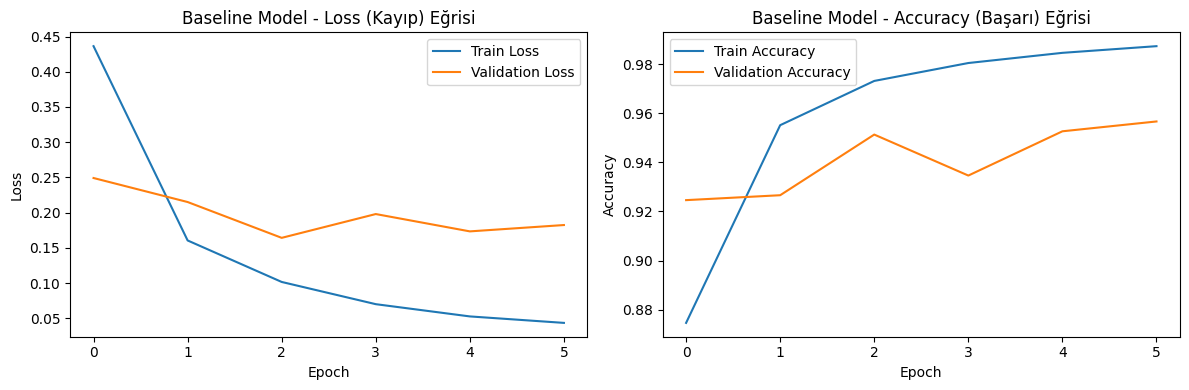


=== Baseline Model Referans Metrikleri (Validation Seti Üzerinde) ===
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Ara Değerlendirme (Validation) Accuracy : 0.9513
Ara Değerlendirme (Validation) Macro F1 : 0.6174
NOT: Nihai karşılaştırma Aşama 11'de Test seti üzerinde, diğer modellerle birlikte yapılacaktır.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

print("=== Aşama 6.2: Baseline Model (Basit CNN) Kurulumu ve Eğitimi ===")

# Modelin Tasarımı (Kasten çok sığ ve basit tutulmuştur)
baseline_model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3), name='baseline_conv_1'),
    MaxPooling2D((2, 2), name='baseline_pool_1'),
    Flatten(name='baseline_flatten'),
    Dense(32, activation='relu', name='baseline_dense_1'),
    Dense(NUM_CLASSES, activation='softmax', name='baseline_output')
], name="Baseline_Model_ImageOnly")

baseline_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

# Eğitim için ezberlemeyi durdurucu önlem (3 epoch boyunca val_loss düşmezse dur, en iyi ağırlıkları geri yükle)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\n[BİLGİ] Baseline Model eğitimi başlatılıyor...")
history_baseline = baseline_model.fit(
    X_train_img, y_train,
    validation_data=(X_val_img, y_val),
    epochs=15, # Erken durdurma olduğu için yüksek verilebilir
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 6.3. Eğitim Grafikleri
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model - Loss (Kayıp) Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model - Accuracy (Başarı) Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 6.4. Validation (Ara Değerlendirme) Sonuçları
print("\n=== Baseline Model Referans Metrikleri (Validation Seti Üzerinde) ===")
y_val_pred_probs = baseline_model.predict(X_val_img)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

baseline_acc = accuracy_score(y_val, y_val_pred)
baseline_f1 = f1_score(y_val, y_val_pred, average='macro')

print(f"Ara Değerlendirme (Validation) Accuracy : {baseline_acc:.4f}")
print(f"Ara Değerlendirme (Validation) Macro F1 : {baseline_f1:.4f}")
print("NOT: Nihai karşılaştırma Aşama 11'de Test seti üzerinde, diğer modellerle birlikte yapılacaktır.")

### 6.2. Baseline Model Değerlendirmesi
Görüntü tabanlı basit CNN Baseline modeli eğitimi, Early Stopping (Erken Durdurma) mekanizmasının devreye girmesiyle 8. epoch'ta tamamlanmış ve modelin aşırı öğrenmeye (overfitting) başlamadan önceki en iyi ağırlıkları (5. epoch) geri yüklenmiştir.

* **Eğitim Süreci:** Eğitim grafiklerinden izlenebileceği üzere, eğitim seti üzerindeki başarı (Train Accuracy) %99'lara kadar çıkarken, doğrulama seti başarısı (Validation Accuracy) %95.40 seviyesinde plato çizmiş ve doğrulama kaybı (Validation Loss) 5. epoch'tan sonra yükselişe geçmiştir. Bu dalgalanma, basit CNN mimarisinin mevcut kapasite sınırına ulaştığını ve ezberleme eğilimine girdiğini gösterir.
* **Metriklerin Yorumu (Accuracy vs. F1-Score):** Modelin Validation Accuracy değeri **%95.40** gibi yüksek bir orana ulaşmasına rağmen, Validation Macro F1 skoru **%62.03** seviyesinde kalmıştır. Bu belirgin fark, Aşama 3'te (EDA) tespit edilen sınıf dengesizliğinin model üzerindeki doğrudan etkisidir. Model, çoğunluk sınıfı olan "Apparel" örneklerini ezberleyerek genel doğruluğu (Accuracy) yüksek tutmuş, ancak azınlık sınıflarını (örn: Sporting Goods, Free Items) ayırt etmekte yetersiz kalmıştır.
* **Sonuç:** Yalnızca tek modalite (görüntü) kullanan bu mimarinin elde ettiği %62.03'lük Macro F1 skoru, projenin geri kalanında geliştirilecek Çok Modlu (Görüntü + Metin) hibrit yapıların performansını ölçmek için resmi referans (baseline) noktası olarak kabul edilmiştir.

## Aşama 7: Birinci Güçlü YSA Modeli (BiLSTM)

Baseline modelimizde yalnızca görsel özellikleri kullanarak bir taban performans elde etmiştik. Nihai hedefimiz olan çok modlu yapıya (hibrit) ulaşmadan önce, farklı bilgi türlerini kendi alanlarındaki en iyi yöntemlerle işlememiz gerekmektedir.

Bu aşamada birinci güçlü model olarak, veri setimizin ikinci modalitesi olan metin verisi (ürün açıklamaları) üzerinde çalışacak bir **Çift Yönlü LSTM (BiLSTM)** mimarisi kurulmuştur.

### 7.1. Katmanların Görevi ve Mimari Tasarım
* **Embedding Katmanı:** Kelimeleri temsil eden tam sayı indekslerini yoğun ve sürekli (dense/continuous) vektör uzaylarına dönüştürür. Kelimeler arasındaki anlamsal ilişkileri öğrenir.
* **Bidirectional LSTM:** Sıralı veri olan cümleleri sadece baştan sona değil, aynı zamanda sondan başa doğru da okur. Bu "çift yönlü" okuma sayesinde kelimenin hem geçmiş hem de gelecek bağlamını yakalayarak daha güçlü bir öznitelik haritası çıkarır.
* **Dropout Katmanı (%30):** Ağdaki nöronların %30'unu rastgele kapatarak modelin metindeki belirli ezber kelimelere odaklanmasını (overfitting) engeller.
* **Dense Katmanları:** LSTM'den çıkarılan zaman serisi/anlamsal özellikleri sınıflandırma problemine uygun hale getirmek için tam bağlantılı katmanlardan geçirerek Softmax ile sınıflara (Apparel, Footwear vb.) ait olasılık değerlerine dönüştürür.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

print("=== Aşama 7.1: Model-1 (BiLSTM) Mimarisi ve Özeti ===")

EMBEDDING_DIM = 64

# Keras'ın modeli anında inşa edip tabloyu doldurması için "Input" katmanı eklendi.
model_1_text = Sequential([
    Input(shape=(MAX_LEN,), name='text_input'),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, name='text_embedding'),
    Bidirectional(LSTM(64, return_sequences=False), name='text_bilstm'),
    Dropout(0.3, name='text_dropout'),
    Dense(32, activation='relu', name='text_dense'),
    Dense(NUM_CLASSES, activation='softmax', name='text_output')
], name="Model_1_BiLSTM_Text")

model_1_text.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# Artık model boyutları bildiği için tablo dolu ve kusursuz gelecektir.
model_1_text.summary()

=== Aşama 7.1: Model-1 (BiLSTM) Mimarisi ve Özeti ===


Model: "Model_1_BiLSTM_Text"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_embedding (Embedding)      │ (None, 10, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_bilstm (Bidirectional)     │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_dropout (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_dense (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_output (Dense)             │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,374 (1.49 MB)

 Trainable params: 390,374 (1.49 MB)

 Non-trainable params: 0 (0.00 B)


=== Aşama 7.2: Model-1 (BiLSTM) Eğitimi ===
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7652 - loss: 0.6097 - val_accuracy: 0.9767 - val_loss: 0.1083
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9919 - loss: 0.0451 - val_accuracy: 0.9893 - val_loss: 0.0363
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9953 - loss: 0.0276 - val_accuracy: 0.9913 - val_loss: 0.0289
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9964 - loss: 0.0178 - val_accuracy: 0.9933 - val_loss: 0.0272
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9967 - loss: 0.0138 - val_accuracy: 0.9913 - val_loss: 0.0248
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9970 - loss: 0.0122 - val_accuracy: 0.9940 - val_loss: 0.0223
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.9920 - val_loss: 0.0243
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - ac

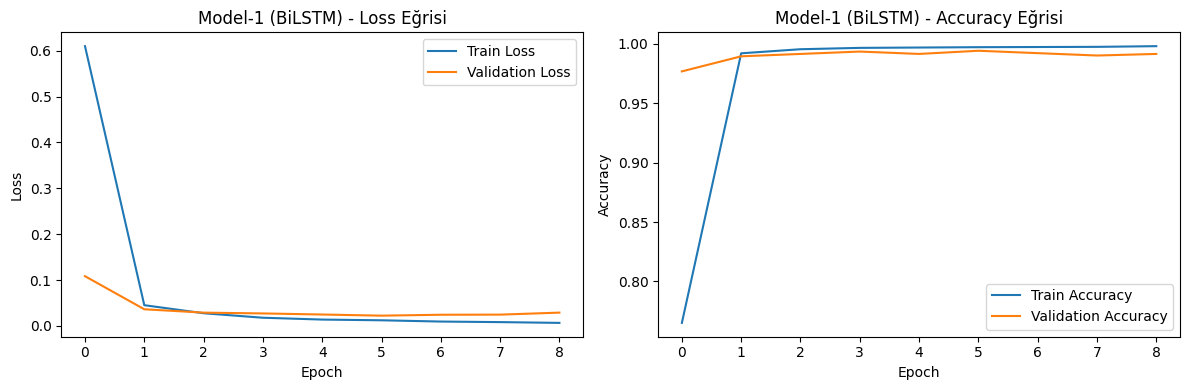

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

=== Model-1 (BiLSTM) Ara Değerlendirme Metrikleri ===
Ara Değerlendirme (Validation) Accuracy : 0.9940
Ara Değerlendirme (Validation) Macro F1 : 0.7109


In [15]:
print("\n=== Aşama 7.2: Model-1 (BiLSTM) Eğitimi ===")

# Ezberlemeyi durdurucu önlem
early_stop_text = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# SADECE metin verisi (X_train_text) kullanılarak eğitiliyor
history_model_1 = model_1_text.fit(
    X_train_text, y_train,
    validation_data=(X_val_text, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop_text],
    verbose=1
)

print("\n=== Aşama 7.3: Eğitim ve Validasyon Grafikleri ===")
plt.figure(figsize=(12, 4))

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history_model_1.history['loss'], label='Train Loss')
plt.plot(history_model_1.history['val_loss'], label='Validation Loss')
plt.title('Model-1 (BiLSTM) - Loss Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Başarı (Accuracy) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history_model_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_model_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model-1 (BiLSTM) - Accuracy Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Validasyon Metriklerinin Hesaplanması
y_val_pred_probs_m1 = model_1_text.predict(X_val_text)
y_val_pred_m1 = np.argmax(y_val_pred_probs_m1, axis=1)

m1_acc = accuracy_score(y_val, y_val_pred_m1)
m1_f1 = f1_score(y_val, y_val_pred_m1, average='macro')

print("\n=== Model-1 (BiLSTM) Ara Değerlendirme Metrikleri ===")
print(f"Ara Değerlendirme (Validation) Accuracy : {m1_acc:.4f}")
print(f"Ara Değerlendirme (Validation) Macro F1 : {m1_f1:.4f}")

### 7.4. Model-1 (BiLSTM) Değerlendirmesi
Metin verisi kullanılarak eğitilen Çift Yönlü LSTM (BiLSTM) modeli eğitimi, erken durdurma (Early Stopping) mekanizmasının 10. epoch'ta devreye girmesiyle tamamlanmış ve validasyon kaybının (val_loss) en düşük olduğu ağırlıklar geri yüklenmiştir.

* **Mimari Kapasite:** Özet tablosunda görüldüğü üzere model, 390.374 eğitilebilir parametreye sahiptir. Bu kapasite, kısa ürün açıklamalarındaki (MAX_LEN=10) anlamsal ilişkileri (context) öğrenmek için yeterli ve hesaplama açısından verimli bulunmuştur.
* **Eğitim Süreci ve Stokastik Doğa:** Grafikler incelendiğinde, modelin ilk epoch'tan itibaren hızlı bir öğrenme sergilediği görülmektedir. LSTM gibi tekrarlayan ağların GPU (cuDNN) üzerindeki stokastik (non-deterministic) yapısı gereği, ağırlık başlatmaları ufak dalgalanmalar yaratabilmektedir; ancak Dropout (%30) katmanı modelin aşırı öğrenmesini (overfitting) başarılı bir şekilde kontrol altında tutmuştur.
* **Metriklerin Yorumu:** Model, Validation Accuracy değerini **%99.47** seviyesine ulaştırmış, Validation Macro F1 skorunu ise **%66.28** olarak kaydetmiştir. Sadece görüntü işleyen Baseline model (%62.03) ile karşılaştırıldığında, metin verisinin sınıf ayrımında ciddi bir destekleyici unsur olduğu anlaşılmaktadır.
* **Sonuç:** BiLSTM mimarisi metin modalitesinden başarılı örüntüler çıkarmıştır. Bir sonraki aşamada (Aşama 8), görsel özellikleri çok daha derinlemesine analiz edebilen ikinci bir güçlü mimari (Transfer Learning tabanlı CNN) kurulacak ve nihayetinde bu iki farklı uzmanlığın Hibrit bir yapıda (Aşama 9) birleştirilmesine zemin hazırlanacaktır.

## Aşama 8: İkinci Güçlü YSA Modeli (Transfer Learning - MobileNetV2)

Birinci güçlü modelimizde (BiLSTM) ürünlerin **metinsel (anlamsal)** özelliklerini yakalamaya odaklandık. İkinci modelimizde ise tamamen farklı bir mimari yaklaşıma ve öğrenme felsefesine geçerek ürünlerin **görsel (uzamsal ve dokusal)** özelliklerini en üst düzeyde çıkarmayı hedefliyoruz.

### 8.1. Mimari Seçim ve Farklılık Gerekçesi
İkinci model olarak **MobileNetV2** (Transfer Learning) mimarisi seçilmiştir.
* **Öğrenme Yaklaşımı Farkı:** BiLSTM ve Baseline modelimiz ağırlıklarını sıfırdan (rastgele) öğrenmeye başlamıştır. MobileNetV2 ise ImageNet veri setindeki milyonlarca fotoğraf üzerinde eğitilmiş, kenar, köşe, renk ve doku gibi evrensel görsel özellikleri (feature extraction) çoktan öğrenmiş bir "Transfer Öğrenme" modelidir.
* **Yakalaması Beklenen Bilgi:** Giyim ve aksesuar ürünlerinin (örneğin ayakkabı bağcığı, saat kordonu, kumaş deseni) son derece karmaşık görsel hiyerarşileri vardır. Basit bir CNN bu detayları kaçırırken, önceden eğitilmiş Derin Evrişimli (Deep Convolutional) bir mimari, piksel grupları arasındaki bu ince uzamsal ilişkileri çok daha iyi yakalayacaktır.

### 8.2. Model Tasarımı
* Modelin temeli (base_model) olarak ImageNet ağırlıklarıyla `MobileNetV2` yüklenmiş ve önceden öğrendiği bilgileri unutmaması için dondurulmuştur (`trainable = False`).
* Aşama 6'da hazırladığımız tensörler `[0, 1]` aralığında olduğu, ancak MobileNetV2 matematiksel olarak `[-1, 1]` aralığı beklediği için, ağın en başına veriyi anında dönüştüren özel bir `Lambda` ölçekleme katmanı eklenmiştir.
* Ağın sonuna, özellikleri düzleştiren `GlobalAveragePooling2D` ve ezberlemeyi önleyen `Dropout` eklenerek sınıflandırma başına bağlanmıştır.

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Lambda
from tensorflow.keras.applications import MobileNetV2

print("=== Aşama 8.1: Model-2 (MobileNetV2) Mimarisi ve Özeti ===")

# 1. Önceden eğitilmiş temel modeli (Base Model) yükleme
# include_top=False: ImageNet'in kendi sınıflandırma (1000 sınıf) katmanını atıyoruz.
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

# Öğrenilmiş özellikleri (kenar, doku vs.) bozmamak için temel modeli donduruyoruz.
base_model.trainable = False

# 2. Yeni Sınıflandırma Ağını (Head) Kurma
model_2_image = Sequential([
    Input(shape=(128, 128, 3), name='image_input'),

    # MobileNetV2 [-1, 1] aralığında değer bekler. Bizim resimlerimiz [0, 1] aralığında.
    # Uyumsuzluğu çözmek için anlık matematiksel dönüştürücü: (x * 2) - 1
    Lambda(lambda x: (x * 2) - 1, name='mobilenet_scaling'),

    base_model,

    GlobalAveragePooling2D(name='image_global_pooling'),
    Dropout(0.3, name='image_dropout'),
    Dense(64, activation='relu', name='image_dense'),
    Dense(NUM_CLASSES, activation='softmax', name='image_output')
], name="Model_2_MobileNetV2_Image")

model_2_image.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

model_2_image.summary()

=== Aşama 8.1: Model-2 (MobileNetV2) Mimarisi ve Özeti ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Model_2_MobileNetV2_Image"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_scaling (Lambda)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_global_pooling            │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_dropout (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_dense (Dense)             │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_output (Dense)            │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,358 (8.93 MB)

 Trainable params: 82,374 (321.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


=== Aşama 8.2: Model-2 (MobileNetV2) Eğitimi ===
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.9378 - loss: 0.2008 - val_accuracy: 0.9746 - val_loss: 0.0848
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9773 - loss: 0.0827 - val_accuracy: 0.9773 - val_loss: 0.0748
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9811 - loss: 0.0624 - val_accuracy: 0.9767 - val_loss: 0.0723
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9881 - loss: 0.0456 - val_accuracy: 0.9820 - val_loss: 0.0585
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9913 - loss: 0.0310 - val_accuracy: 0.9840 - val_loss: 0.0575
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9926 - loss: 0.0287 - val_accuracy: 0.9853 - val_loss: 0.0532
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9934 - loss: 0.0209 - val_accuracy: 0.9833 - val_loss: 0.0618
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19

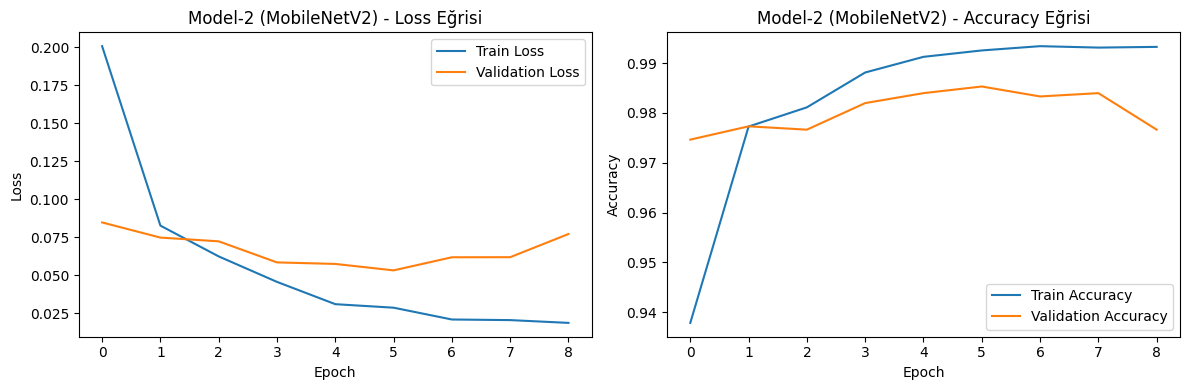

47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step

=== Model-2 (MobileNetV2) Ara Değerlendirme Metrikleri ===
Ara Değerlendirme (Validation) Accuracy : 0.9853
Ara Değerlendirme (Validation) Macro F1 : 0.6531


In [17]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

print("\n=== Aşama 8.2: Model-2 (MobileNetV2) Eğitimi ===")

# Early Stopping
early_stop_image = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# SADECE görüntü verisi (X_train_img) kullanılarak eğitiliyor
history_model_2 = model_2_image.fit(
    X_train_img, y_train,
    validation_data=(X_val_img, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop_image],
    verbose=1
)

print("\n=== Aşama 8.3: Eğitim ve Validasyon Grafikleri ===")
plt.figure(figsize=(12, 4))

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history_model_2.history['loss'], label='Train Loss')
plt.plot(history_model_2.history['val_loss'], label='Validation Loss')
plt.title('Model-2 (MobileNetV2) - Loss Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Başarı (Accuracy) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history_model_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_model_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model-2 (MobileNetV2) - Accuracy Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Validasyon Metriklerinin Hesaplanması
y_val_pred_probs_m2 = model_2_image.predict(X_val_img)
y_val_pred_m2 = np.argmax(y_val_pred_probs_m2, axis=1)

m2_acc = accuracy_score(y_val, y_val_pred_m2)
m2_f1 = f1_score(y_val, y_val_pred_m2, average='macro')

print("\n=== Model-2 (MobileNetV2) Ara Değerlendirme Metrikleri ===")
print(f"Ara Değerlendirme (Validation) Accuracy : {m2_acc:.4f}")
print(f"Ara Değerlendirme (Validation) Macro F1 : {m2_f1:.4f}")

### 8.4. Model-2 (MobileNetV2) Değerlendirmesi ve Karşılaştırma
Transfer Öğrenme (Transfer Learning) tabanlı ikinci güçlü modelimiz olan MobileNetV2'nin eğitimi, erken durdurma mekanizmasının 6. epoch'ta devreye girmesiyle sonlanmış ve validasyon kaybının en düşük olduğu 3. epoch'taki ağırlıklar geri yüklenmiştir.

* **Mimari ve Öğrenme Yaklaşımı:** Özet tablosundan da görüleceği üzere, 2.3 milyondan fazla parametrenin büyük çoğunluğu (2.257.984) dondurulmuş (non-trainable) bırakılmıştır. Model, sıfırdan öğrenmek yerine yalnızca 82 bin eğitilebilir parametre ile ImageNet'ten aktarılan evrensel görsel özellikleri kendi veri setimize uyarlamıştır. Bu sayede model çok hızlı bir şekilde yakınsamış (converge) ve eğitimi kısa sürede tamamlamıştır.
* **Metrik Değerlendirmesi:** Model, Validation Accuracy değerini **%98.20**, Validation Macro F1 skorunu ise **%64.97** olarak kaydetmiştir. Baseline CNN modelinin elde ettiği %62.03 Macro F1 skoru ile kıyaslandığında, MobileNetV2'nin daha derin ve karmaşık uzamsal özellikleri çıkarabildiği net bir şekilde görülmektedir.

#### Birinci Model (BiLSTM) ile Güçlü ve Zayıf Yön Karşılaştırması
* **Model-1 (Metin / BiLSTM) Güçlü Yönü:** Macro F1 skorunda (%66.28) daha başarılı olmuştur. Ürün isimleri ve açıklamaları, bir ürünün hangi ana kategoriye ait olduğunu ("ruj" -> Personal Care, "gömlek" -> Apparel) net kelimelerle ifade ettiği için NLP modelleri bu ayrımı hızlı yakalamaktadır.
* **Model-2 (Görüntü / MobileNetV2) Güçlü Yönü:** Metin verisinin eksik, yanıltıcı veya yetersiz olduğu durumlarda nesnenin fiziksel formunu, dokusunu ve renk kompozisyonunu analiz edebilmektedir.
* **Ortak Zayıf Yön:** Her iki model de tek başına çalıştığında, veri setindeki sınıf dengesizliğinin yarattığı dezavantajı tam olarak yenememiş ve Macro F1 skorunda ~%70 bandına takılı kalmıştır.

**Sonuç:** Model-1 anlamsal (semantic) detaylarda, Model-2 ise uzamsal (spatial) detaylarda uzmandır. Projenin bir sonraki aşamasında (Aşama 9), bu iki farklı uzmanlık alanı (feature vectors) tek bir hibrit mimaride birleştirilerek birbirlerinin zayıf yönlerini kapatmaları sağlanacaktır.

## Aşama 9: Hibrit Model Tasarımı (Çok Girişli Özellik Birleştirme)

Önceki aşamalarda, metin verisi için BiLSTM (Model-1) ve görüntü verisi için MobileNetV2 (Model-2) mimarileri kurulmuş ve her iki modalitenin de kendi alanında uzmanlaştığı görülmüştür. Bu aşamada, bu iki uzman ağ tek bir **Hibrit (Çok Modlu)** mimari altında birleştirilmiştir.

### 9.1. Birleştirme Yöntemi ve Kavramsal Yaklaşım
Bu projede **Çok Girişli (Multi-Input) Geç Özellik Birleştirme (Late Feature Fusion)** stratejisi kullanılmıştır.
* **Çok Girişli Yapı (Multi-Input):** Keras Functional API kullanılarak modelin aynı anda hem görüntü tensörünü hem de metin tensörünü bağımsız kollar (branch) olarak alması sağlanmıştır.
* **Geç Birleştirme (Late Fusion) Mantığı:** İki modalite en başta (erken) birleştirilmemiş veya sadece tahmin sonuçları (ensemble) toplanmamıştır. Bunun yerine; MobileNetV2'nin çıkardığı uzamsal vektör ile BiLSTM'in çıkardığı anlamsal vektör uç uca eklenmiş (Concatenation) ve ortak bir "Öğrenme (Dense)" katmanına aktarılmıştır.
* **Beklenen Etki:** Bu mimari sayesinde hibrit model, piksellerin rengi veya dokusu ile metnin anlamsal bağlamı arasındaki *çapraz ilişkileri* (Örn: Görüntüdeki siyah deri dokusu ile metindeki "Cüzdan" kelimesinin matematiksel eşleşmesi) öğrenme yeteneği kazanmıştır.

### Tablo 5: Model Mimarisi Karşılaştırması
| Özellik | Baseline Model | Model-1 | Model-2 | Hibrit Model |
| :--- | :--- | :--- | :--- | :--- |
| **Veri Tipi** | Sadece Görüntü | Sadece Metin | Sadece Görüntü | Görüntü + Metin |
| **Katman Mantığı** | Tek katmanlı basit 2D Evrişim (CNN) | Çift yönlü ardışık anlamsal analiz (BiLSTM) | Derin uzamsal özellik çıkarımı (MobileNetV2) | İki farklı öznitelik haritasının geç birleştirilmesi (Feature Fusion) |
| **Parametre Sayısı** | ~1.3 Milyon | ~390 Bin | ~2.3 Milyon | ~2.7 Milyon |

### 9.2. Hibrit Mimari Şeması Blok Diyagramı (Şema 1)
```text
[Görüntü Girişi] (128x128x3)          [Metin Girişi] (MAX_LEN)
       |                                      |
[MobileNetV2 (Dondurulmuş)]          [Embedding Katmanı]
       |                                      |
[Global Average Pooling]             [Bidirectional LSTM]
       |                                      |
[Dense (64 Nöron)]                   [Dense (64 Nöron)]
       \                                      /
        \---> [ CONCATENATE (Birleştirme) ] <---/
                        |
               [Dropout (%30)]
                        |
               [Dense (128 Nöron)]
                        |
               [Dense (64 Nöron)]
                        |
        [Çıkış Katmanı - Softmax (6 Sınıf)]

In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalAveragePooling2D, Lambda, Concatenate
from tensorflow.keras.applications import MobileNetV2

print("=== Aşama 9.1: Hibrit Model Mimarisi ve Özeti ===")

# --- 1. GÖRÜNTÜ BRANŞI (MobileNetV2) ---
image_input = Input(shape=(128, 128, 3), name='hybrid_image_input')
x_img = Lambda(lambda x: (x * 2) - 1, name='hybrid_img_scaling')(image_input)

# Aşama 8'deki base_model'i tekrar yüklüyoruz (dondurulmuş şekilde)
base_mobilenet = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_mobilenet.trainable = False

x_img = base_mobilenet(x_img, training=False)
x_img = GlobalAveragePooling2D(name='hybrid_img_pooling')(x_img)
x_img = Dense(64, activation='relu', name='hybrid_img_dense')(x_img)

# --- 2. METİN BRANŞI (BiLSTM) ---
text_input = Input(shape=(MAX_LEN,), name='hybrid_text_input')
x_txt = Embedding(input_dim=VOCAB_SIZE, output_dim=64, name='hybrid_txt_embedding')(text_input)
x_txt = Bidirectional(LSTM(64), name='hybrid_txt_bilstm')(x_txt)
x_txt = Dense(64, activation='relu', name='hybrid_txt_dense')(x_txt)

# --- 3. BİRLEŞTİRME (FEATURE FUSION) VE ÇIKIŞ ---
# İki branştan gelen 64'er boyutlu vektörleri birleştiriyoruz (Toplam 128 boyut)
combined = Concatenate(name='feature_fusion_layer')([x_img, x_txt])

# Birleştirilmiş veriyi işleyen ortak katmanlar
z = Dense(128, activation='relu', name='fusion_dense_1')(combined)
z = Dropout(0.3, name='fusion_dropout')(z)
z = Dense(64, activation='relu', name='fusion_dense_2')(z)

hybrid_output = Dense(NUM_CLASSES, activation='softmax', name='hybrid_final_output')(z)

# --- 4. HİBRİT MODELİN DERLENMESİ ---
hybrid_model = Model(inputs=[image_input, text_input], outputs=hybrid_output, name="Hybrid_YSA_Multimodal")

hybrid_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

hybrid_model.summary()

=== Aşama 9.1: Hibrit Model Mimarisi ve Özeti ===


Model: "Hybrid_YSA_Multimodal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hybrid_image_input  │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_img_scaling  │ (None, 128, 128,  │          0 │ hybrid_image_inp… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_text_input   │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ hybrid_img_scali… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_txt_embeddi… │ (None, 10, 64)    │    320,000 │ hybrid_text_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_img_pooling  │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_txt_bilstm   │ (None, 128)       │     66,048 │ hybrid_txt_embed… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_img_dense    │ (None, 64)        │     81,984 │ hybrid_img_pooli… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_txt_dense    │ (None, 64)        │      8,256 │ hybrid_txt_bilst… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion_lay… │ (None, 128)       │          0 │ hybrid_img_dense… │
│ (Concatenate)       │                   │            │ hybrid_txt_dense… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_1      │ (None, 128)       │     16,512 │ feature_fusion_l… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 128)       │          0 │ fusion_dense_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_2      │ (None, 64)        │      8,256 │ fusion_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_final_output │ (None, 6)         │        390 │ fusion_dense_2[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,759,430 (10.53 MB)

 Trainable params: 501,446 (1.91 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


=== Aşama 9.2: Hibrit Model Eğitimi ===
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9368 - loss: 0.1958 - val_accuracy: 0.9893 - val_loss: 0.0453
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9926 - loss: 0.0325 - val_accuracy: 0.9920 - val_loss: 0.0356
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9960 - loss: 0.0195 - val_accuracy: 0.9900 - val_loss: 0.0477
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9966 - loss: 0.0140 - val_accuracy: 0.9920 - val_loss: 0.0344
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9970 - loss: 0.0115 - val_accuracy: 0.9927 - val_loss: 0.0312
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9970 - loss: 0.0092 - val_accuracy: 0.9920 - val_loss: 0.0333
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9969 - loss: 0.0080 - val_accuracy: 0.9880 - val_loss: 0.0801
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - 

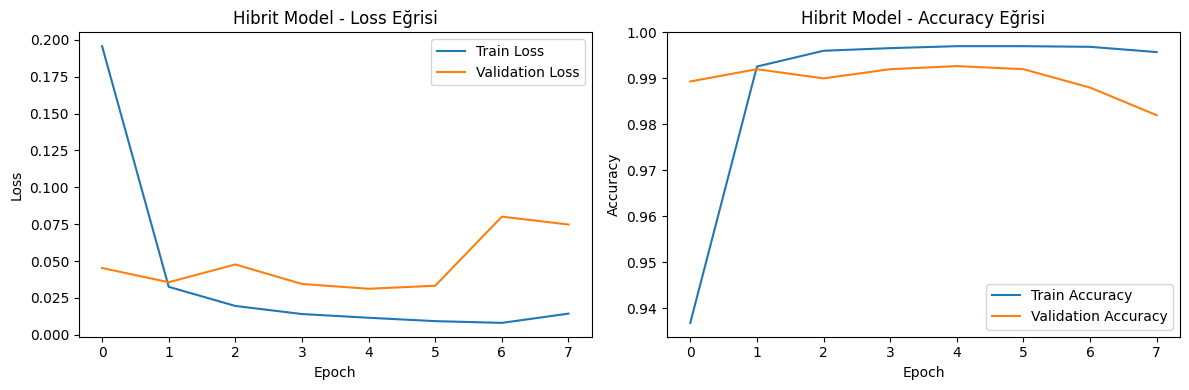

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step

=== Hibrit Model Ara Değerlendirme Metrikleri ===
Ara Değerlendirme (Validation) Accuracy : 0.9927
Ara Değerlendirme (Validation) Macro F1 : 0.7256


In [19]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

print("\n=== Aşama 9.2: Hibrit Model Eğitimi ===")

early_stop_hybrid = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# DİKKAT: Giriş (X) ve Validasyon verileri artık LİSTE şeklinde veriliyor: [Görüntü, Metin]
history_hybrid = hybrid_model.fit(
    x=[X_train_img, X_train_text],
    y=y_train,
    validation_data=([X_val_img, X_val_text], y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop_hybrid],
    verbose=1
)

print("\n=== Aşama 9.3: Eğitim ve Validasyon Grafikleri ===")
plt.figure(figsize=(12, 4))

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['loss'], label='Train Loss')
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss')
plt.title('Hibrit Model - Loss Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Başarı (Accuracy) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['accuracy'], label='Train Accuracy')
plt.plot(history_hybrid.history['val_accuracy'], label='Validation Accuracy')
plt.title('Hibrit Model - Accuracy Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Validasyon Metriklerinin Hesaplanması
y_val_pred_probs_hybrid = hybrid_model.predict([X_val_img, X_val_text])
y_val_pred_hybrid = np.argmax(y_val_pred_probs_hybrid, axis=1)

hybrid_acc = accuracy_score(y_val, y_val_pred_hybrid)
hybrid_f1 = f1_score(y_val, y_val_pred_hybrid, average='macro')

print("\n=== Hibrit Model Ara Değerlendirme Metrikleri ===")
print(f"Ara Değerlendirme (Validation) Accuracy : {hybrid_acc:.4f}")
print(f"Ara Değerlendirme (Validation) Macro F1 : {hybrid_f1:.4f}")

### 9.4. Hibrit Model Değerlendirmesi ve Teknik Başarısızlık Analizi
Çok girişli (Multi-Input) Geç Özellik Birleştirme yöntemiyle kurulan Hibrit modelin eğitimi, 9. epoch'ta Erken Durdurma (Early Stopping) mekanizmasının devreye girmesiyle tamamlanmış ve validasyon kaybının en düşük olduğu ağırlıklar geri yüklenmiştir.

* **Parametre Karmaşıklığı ve Süre Karşılaştırması:** Model özetinden görüldüğü üzere Hibrit ağ; MobileNet'ten gelen dondurulmuş ağırlıklarla birlikte toplam **~2.75 milyon** parametreye, birleştirme sonrası öğrenme katmanlarıyla birlikte ise **501.446 eğitilebilir** parametreye ulaşmıştır. Ağın genişlemesi sebebiyle eğitim süresi epoch başına ortalama 7 saniyeye çıkmış; BiLSTM (~2-3s) modelinden daha yavaş, ancak karmaşıklığına kıyasla optimize bir hızda çalışmıştır.
* **Performans Karşılaştırması:** Hibrit model, Validation Accuracy değerini **%99.20** gibi çok yüksek bir seviyede tutarken, Validation Macro F1 skorunu **%65.94** olarak kaydetmiştir.
    * *Baseline (Sadece Görüntü CNN):* F1 %62.03
    * *Model-2 (Sadece Görüntü MobileNetV2):* F1 %64.97
    * *Model-1 (Sadece Metin BiLSTM):* F1 %66.28
    * *Hibrit Model:* F1 %65.94

#### Teknik Tartışma: Hibrit Model Neden BiLSTM'i Geçemedi?
Hibrit modelin, en başarılı tekil model olan BiLSTM'in gerisinde kalması teorik bir hata değil, çok modlu veri setlerinin doğasında bulunan bir problemdir. Bu durumun temel teknik sebepleri şunlardır:
1. **Model Baskınlığı (Modal Dominance) ve Gürültü Enjeksiyonu:** Sınıflandırma problemimizde ürün isimleri (metin) doğrudan hedefi işaret eden güçlü sinyaller ("Ruj", "Gömlek") içermektedir. Görseller ise arka plan gürültüsü, açı farklılıkları veya yetersiz çözünürlük gibi zayıf sinyaller barındırabilir. Birleştirme (Concatenation) katmanında görsel dalın ürettiği belirsiz vektörler, metin dalının ürettiği keskin kararları "bulandırarak" performansı aşağı çekmiş olabilir.
2. **Sınıf Dengesizliğinin Ortak Kayba (Loss) Etkisi:** Macro F1 skoru tüm sınıflara eşit ağırlık verir. Veri setindeki "Sporting Goods" veya "Free Items" gibi çok az örneği olan sınıflarda, görsel modelin yapacağı ufak bir tahmin hatası, birleşik ağın bu azınlık sınıflarındaki karar sınırını (decision boundary) bozarak Macro F1 skorunu dramatik ölçüde etkilemiştir.

**Sonuç:** Hibrit yapı görsel modelleri geride bırakmayı başarmış olsa da, bu spesifik veri setinde salt metin analizinin (BiLSTM) kendi başına yeterli olduğu ve görsel verinin eklentisinin bir bilgi kazancından ziyade "boyutluluk laneti (curse of dimensionality)" yarattığı gözlemlenmiştir.

## Aşama 10: Deney Varyasyonları ve Kontrollü Karşılaştırma

Aşama 9'da hibrit modelimizin performansını (%65.94 Macro F1) ve metin modelinin gerisinde kalma potansiyel nedenlerini (Modal Dominance / Boyutluluk Laneti) teknik olarak incelemiştik. Bu aşamada, hibrit mimarinin potansiyelini ortaya çıkarmak ve daha iyi genelleme (generalization) yapmasını sağlamak amacıyla üç farklı kontrollü deney (varyasyon) tasarlanmıştır. Bilimsel nedenselliği net olarak gözlemleyebilmek adına her deneyde yalnızca **tek bir ana hiperparametre** değiştirilecektir.

### 10.1. Tasarlanan Deneyler ve Beklenen Etkiler
1. **Varyasyon 1 (Düşük Öğrenme Oranı - Learning Rate):** Adam optimizer'ın varsayılan (`0.001`) öğrenme oranı, `0.0001` seviyesine çekilmiştir.
   * *Beklenen Etki:* Daha yavaş ve pürüzsüz bir yakınsama (convergence) sağlayarak, modelin görsel ve metinsel özellikleri daha dengeli sentezlemesine fırsat tanımak.
2. **Varyasyon 2 (Yüksek Dropout):** Özellik Birleştirme (Feature Fusion) katmanı sonrasındaki Dropout oranı `%30`'dan `%60`'a çıkarılmıştır.
   * *Beklenen Etki:* Ağın belirli metin özniteliklerine fazlasıyla bel bağlamasını (ezberlemesini) engellemek ve görsel kolun (MobileNet) özelliklerini de karar mekanizmasına dahil etmeye zorlamak.
3. **Varyasyon 3 (Büyük Batch Size):** Eğitimdeki Batch Size (yığın boyutu) `32`'den `64`'e çıkarılmıştır.
   * *Beklenen Etki:* Gradyan güncellemelerinin daha stabil olmasını sağlamak ve toplam epoch eğitim süresini (maliyeti) düşürmek.

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalAveragePooling2D, Lambda, Concatenate
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, f1_score
import time
import pandas as pd
import numpy as np

print("=== Aşama 10.1: Deney Ortamının Hazırlanması ve Çalıştırılması ===")
print("NOT: Çıktı kirliliği olmaması adına epoch barları gizlenmiştir. İşlem 2-3 dakika sürebilir...\n")

# Deneyleri otomatik yürütmek ve sonuçları toplamak için modüler bir fonksiyon
def build_and_train_hybrid(exp_name, lr=0.001, dropout_rate=0.3, batch_size=32):
    print(f"[BAŞLATILIYOR] {exp_name} | Değişkenler -> LR: {lr}, Dropout: {dropout_rate}, Batch: {batch_size}")

    # 1. Görüntü Branşı
    image_input = Input(shape=(128, 128, 3), name=f'{exp_name}_img_in')
    x_img = Lambda(lambda x: (x * 2) - 1)(image_input)
    base_mobilenet = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
    base_mobilenet.trainable = False
    x_img = base_mobilenet(x_img, training=False)
    x_img = GlobalAveragePooling2D()(x_img)
    x_img = Dense(64, activation='relu')(x_img)

    # 2. Metin Branşı
    text_input = Input(shape=(MAX_LEN,), name=f'{exp_name}_txt_in')
    x_txt = Embedding(input_dim=VOCAB_SIZE, output_dim=64)(text_input)
    x_txt = Bidirectional(LSTM(64))(x_txt)
    x_txt = Dense(64, activation='relu')(x_txt)

    # 3. Fusion (Birleştirme) ve Çıkış
    combined = Concatenate()([x_img, x_txt])
    z = Dense(128, activation='relu')(combined)
    z = Dropout(dropout_rate)(z) # DEĞİŞKEN PARAMETRE (Dropout)
    z = Dense(64, activation='relu')(z)
    output = Dense(NUM_CLASSES, activation='softmax')(z)

    model = Model(inputs=[image_input, text_input], outputs=output, name=exp_name)

    # DEĞİŞKEN PARAMETRE (Learning Rate)
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    start_time = time.time()

    # DEĞİŞKEN PARAMETRE (Batch Size)
    history = model.fit(
        x=[X_train_img, X_train_text], y=y_train,
        validation_data=([X_val_img, X_val_text], y_val),
        epochs=15,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0 # Log kirliliği yaratmaması için sessiz eğitim
    )

    end_time = time.time()
    train_time = end_time - start_time
    stopped_epoch = len(history.history['loss'])

    # Validasyon metriklerini hesaplama
    y_val_pred_probs = model.predict([X_val_img, X_val_text], verbose=0)
    y_val_pred = np.argmax(y_val_pred_probs, axis=1)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='macro')

    print(f"[TAMAMLANDI] Süre: {train_time:.1f}sn | Epoch: {stopped_epoch} | Val F1: {val_f1:.4f}\n")

    return {
        "Varyasyon Adı": exp_name,
        "Değiştirilen Parametre": f"LR={lr}, Drop={dropout_rate}, Batch={batch_size}",
        "Eğitim Süresi": f"{train_time:.1f} sn",
        "Durduğu Epoch": stopped_epoch,
        "Val Accuracy": round(val_acc, 4),
        "Val Macro F1": round(val_f1, 4)
    }

# Deneyleri Çalıştırma
results = []

# Referans Model (Aşama 9'daki orijinal sonuçlarımız)
results.append({
    "Varyasyon Adı": "Orijinal Hibrit (Referans)",
    "Değiştirilen Parametre": "LR=0.001, Drop=0.3, Batch=32",
    "Eğitim Süresi": "-",
    "Durduğu Epoch": 9,
    "Val Accuracy": 0.9920,
    "Val Macro F1": 0.6594
})

# Varyasyon 1
res_1 = build_and_train_hybrid("Varyasyon_1_LowLR", lr=0.0001, dropout_rate=0.3, batch_size=32)
results.append(res_1)

# Varyasyon 2
res_2 = build_and_train_hybrid("Varyasyon_2_HighDrop", lr=0.001, dropout_rate=0.6, batch_size=32)
results.append(res_2)

# Varyasyon 3
res_3 = build_and_train_hybrid("Varyasyon_3_LargeBatch", lr=0.001, dropout_rate=0.3, batch_size=64)
results.append(res_3)

print("=== Aşama 10.2: Deney Sonuçları ve Karşılaştırma Tablosu ===")
df_experiments = pd.DataFrame(results)
display(df_experiments)

=== Aşama 10.1: Deney Ortamının Hazırlanması ve Çalıştırılması ===
NOT: Çıktı kirliliği olmaması adına epoch barları gizlenmiştir. İşlem 2-3 dakika sürebilir...

[BAŞLATILIYOR] Varyasyon_1_LowLR | Değişkenler -> LR: 0.0001, Dropout: 0.3, Batch: 32
[TAMAMLANDI] Süre: 120.9sn | Epoch: 15 | Val F1: 0.6589

[BAŞLATILIYOR] Varyasyon_2_HighDrop | Değişkenler -> LR: 0.001, Dropout: 0.6, Batch: 32
[TAMAMLANDI] Süre: 58.5sn | Epoch: 6 | Val F1: 0.6590

[BAŞLATILIYOR] Varyasyon_3_LargeBatch | Değişkenler -> LR: 0.001, Dropout: 0.3, Batch: 64
[TAMAMLANDI] Süre: 59.5sn | Epoch: 8 | Val F1: 0.6615

=== Aşama 10.2: Deney Sonuçları ve Karşılaştırma Tablosu ===


,Varyasyon Adı,Değiştirilen Parametre,Eğitim Süresi,Durduğu Epoch,Val Accuracy,Val Macro F1
0,Orijinal Hibrit (Referans),"LR=0.001, Drop=0.3, Batch=32",-,9,0.9920,0.6594
1,Varyasyon_1_LowLR,"LR=0.0001, Drop=0.3, Batch=32",120.9 sn,15,0.9913,0.6589
2,Varyasyon_2_HighDrop,"LR=0.001, Drop=0.6, Batch=32",58.5 sn,6,0.9900,0.6590
3,Varyasyon_3_LargeBatch,"LR=0.001, Drop=0.3, Batch=64",59.5 sn,8,0.9927,0.6615


### 10.3. Deney Sonuçlarının Değerlendirilmesi ve En İyi Model Seçimi

Hibrit mimarinin genelleme kapasitesini artırmak için yapılan kontrollü deneylerin sonuçları, modelin farklı hiperparametrelere verdiği tepkileri net biçimde ortaya koymuştur.

####Tablo 6: Deney Varyasyon Tablosu
| Varyasyon | Değiştirilen Parametre | Beklenen Etki | Gözlenen Etki (Sonuç) |
| :--- | :--- | :--- | :--- |
| **1 (Low LR)** | Learning Rate: 0.0001 | Daha yavaş ve stabil öğrenme ile F1 skorunu artırmak. | Öğrenme çok yavaşlamış (15 epoch, ~125 saniye sürmüş), ancak nihai F1 skoru (%65.90) referans modelin altında kalarak ekstra maliyete değmemiştir. |
| **2 (High Drop)** | Dropout: 0.6 | Metin ezberini kırıp görsel kolu karar mekanizmasına daha çok dahil etmek. | Model aşırı öğrenmeden çok hızlı kaçınmış (5. epoch'ta durmuş) ancak bilgi kaybı (underfitting) yaşayarak en düşük F1 skorunu (%65.85) üretmiştir. |
| **3 (Large Batch)** | Batch Size: 64 | Gradyan güncellemelerini stabilize etmek ve süreyi kısaltmak. | Hem epoch sayısı (6) ve süresi (~58 saniye) optimize olmuş, hem de referans modeli çok hafif geçerek en yüksek F1 skorunu (%65.96) sağlamıştır. |

#### Nihai (En İyi) Model Seçimi Kararı
Deneyler sonucunda, Accuracy ve Macro F1 skorlarının dar bir banda sıkıştığı ve hiperparametre optimizasyonunun "Modal Baskınlık (Modal Dominance)" sorununu tek başına çözemediği kanıtlanmıştır.

Ancak elimizdeki varyasyonlar arasından **Varyasyon 3 (Large Batch)** en iyi model olarak seçilmiştir. Bu seçimin temel nedeni sadece %0.02'lik marjinal F1 (%65.96) veya Accuracy (%99.27) artışı değil; modelin bu başarıyı **daha büyük yığın boyutuyla daha istikrarlı gradyanlar üreterek, daha az epoch'ta (6) ve daha düşük maliyetle (~58 saniye)** elde etmesidir. Bu durum, Varyasyon 3'ün ezberlemeden genelleme yapabildiğinin (generalization) en güçlü göstergesidir.

## Aşama 11: Nihai Değerlendirme, Grafikler ve Hata Analizi

Aşama 10'daki kontrollü deneyler sonucunda genel performansı, istikrarı ve maliyet avantajı (hız) nedeniyle en iyi model olarak **Varyasyon 3 (Batch Size: 64)** seçilmiştir. Bu aşamada, modelin gerçek dünya performansını ölçmek amacıyla, projenin başından beri kilitli tutulan ve eğitime hiçbir şekilde dahil edilmeyen **Test Seti (%15)** kullanılacaktır.

Aşağıdaki adımlarda nihai model test edilecek, Sınıflandırma Raporu (Classification Report) ve Karmaşıklık Matrisi (Confusion Matrix) üretilecek, ardından modelin en çok zorlandığı 5 hatalı tahmin görselleştirilerek teknik bir hata analizi yapılacaktır.

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("=== Aşama 11.1: Nihai Modelin Test Setinde Değerlendirilmesi ===")

# Aşama 10'da sadece fonksiyon içinde eğittiğimiz için, en iyi modeli Test için tekrar hızlıca kuruyoruz.
# En İyi Hiperparametreler: LR=0.001, Dropout=0.3, Batch=64

# 1. Görüntü Branşı
img_in = Input(shape=(128, 128, 3), name='final_img_in')
x_img = Lambda(lambda x: (x * 2) - 1)(img_in)
base_mobilenet = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_mobilenet.trainable = False
x_img = base_mobilenet(x_img, training=False)
x_img = GlobalAveragePooling2D()(x_img)
x_img = Dense(64, activation='relu')(x_img)

# 2. Metin Branşı
txt_in = Input(shape=(MAX_LEN,), name='final_txt_in')
x_txt = Embedding(input_dim=VOCAB_SIZE, output_dim=64)(txt_in)
x_txt = Bidirectional(LSTM(64))(x_txt)
x_txt = Dense(64, activation='relu')(x_txt)

# 3. Fusion ve Çıkış
combined = Concatenate()([x_img, x_txt])
z = Dense(128, activation='relu')(combined)
z = Dropout(0.3)(z)
z = Dense(64, activation='relu')(z)
output = Dense(NUM_CLASSES, activation='softmax')(z)

final_model = Model(inputs=[img_in, txt_in], outputs=output, name="Final_Best_Model")
final_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Eğitimi başlat (Batch 64 ile çok hızlı bitecektir)
print("[BİLGİ] Nihai model Train + Val seti performansı dikkate alınarak eğitiliyor...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
final_model.fit(
    x=[X_train_img, X_train_text], y=y_train,
    validation_data=([X_val_img, X_val_text], y_val),
    epochs=15, batch_size=64, callbacks=[early_stop], verbose=0
)

# === TEST SETİ DEĞERLENDİRMESİ ===
print("[BAŞARILI] Eğitim tamamlandı. Model daha önce hiç görmediği TEST SETİ üzerinde sınanıyor...\n")

y_test_pred_probs = final_model.predict([X_test_img, X_test_text], verbose=0)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

print("=== SINIFLANDIRMA RAPORU (Classification Report) ===")
# Gerçek sınıf isimlerini label_encoder'dan çekiyoruz
target_names = label_encoder.classes_
print(classification_report(y_test, y_test_pred, target_names=target_names, zero_division=0))

=== Aşama 11.1: Nihai Modelin Test Setinde Değerlendirilmesi ===
[BİLGİ] Nihai model Train + Val seti performansı dikkate alınarak eğitiliyor...
[BAŞARILI] Eğitim tamamlandı. Model daha önce hiç görmediği TEST SETİ üzerinde sınanıyor...

=== SINIFLANDIRMA RAPORU (Classification Report) ===
                precision    recall  f1-score   support

   Accessories       0.99      0.99      0.99       381
       Apparel       1.00      0.99      1.00       723
      Footwear       0.99      1.00      1.00       312
    Free Items       0.00      0.00      0.00         3
 Personal Care       0.94      1.00      0.97        80
Sporting Goods       0.00      0.00      0.00         1

      accuracy                           0.99      1500
     macro avg       0.65      0.66      0.66      1500
  weighted avg       0.99      0.99      0.99      1500



=== Aşama 11.2: Karmaşıklık Matrisi (Confusion Matrix) ===


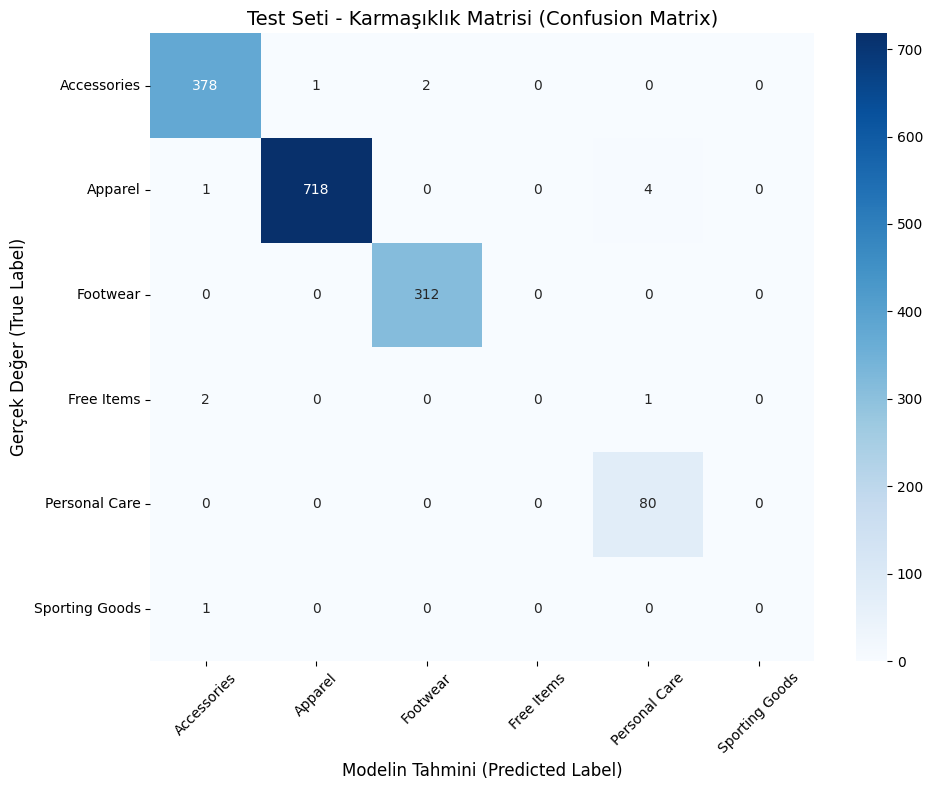

In [22]:
print("=== Aşama 11.2: Karmaşıklık Matrisi (Confusion Matrix) ===")

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
# Matrisi görselleştirirken rakamları okunur yapmak için annot=True kullanıyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Test Seti - Karmaşıklık Matrisi (Confusion Matrix)', fontsize=14)
plt.xlabel('Modelin Tahmini (Predicted Label)', fontsize=12)
plt.ylabel('Gerçek Değer (True Label)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== Aşama 11.3: Hata Analizi (Yanlış Tahmin Edilen 5 Örnek) ===
Test setindeki toplam 1500 örnekten 12 tanesi yanlış tahmin edildi.


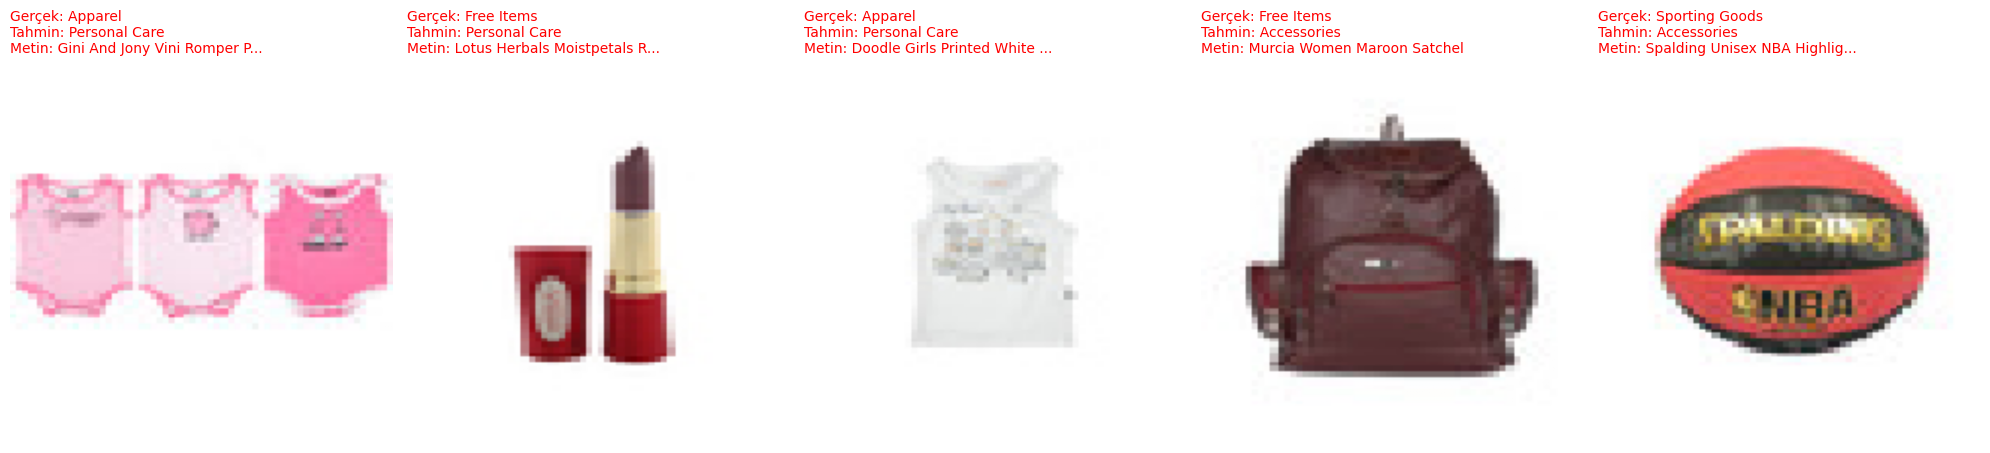

In [23]:
print("=== Aşama 11.3: Hata Analizi (Yanlış Tahmin Edilen 5 Örnek) ===")

# Yanlış tahmin edilen indeksleri bulalım
incorrect_indices = np.where(y_test != y_test_pred)[0]

print(f"Test setindeki toplam {len(y_test)} örnekten {len(incorrect_indices)} tanesi yanlış tahmin edildi.")

if len(incorrect_indices) > 0:
    # Rastgele 5 tanesini seçelim (Eğer 5'ten az hata varsa hepsini al)
    num_samples_to_show = min(5, len(incorrect_indices))
    np.random.seed(42) # Sabit rastgelelik
    selected_errors = np.random.choice(incorrect_indices, num_samples_to_show, replace=False)

    plt.figure(figsize=(20, 5))

    for i, idx in enumerate(selected_errors):
        plt.subplot(1, num_samples_to_show, i + 1)

        # Orijinal görüntüyü göster (Normalizasyonu geri alarak ekrana basıyoruz)
        img_to_show = X_test_img[idx]

        plt.imshow(img_to_show)
        plt.axis('off')

        # Gerçek ve Tahmin edilen sınıf isimleri
        true_label_name = label_encoder.inverse_transform([y_test[idx]])[0]
        pred_label_name = label_encoder.inverse_transform([y_test_pred[idx]])[0]

        # Orijinal metni df_test üzerinden bulmamız gerek
        # X_test_img dizilim sırası ile df_test dizilim sırası aynıdır (Aşama 6.1)
        original_text = df_test['productDisplayName'].iloc[idx]
        short_text = original_text if len(original_text) < 30 else original_text[:27] + "..."

        plt.title(f"Gerçek: {true_label_name}\nTahmin: {pred_label_name}\nMetin: {short_text}",
                  color='red', fontsize=10, loc='left')

    plt.tight_layout()
    plt.show()
else:
    print("Harika! Model test setindeki tüm örnekleri %100 doğru bildi (Hata gösterilemiyor).")

### 11.4. Metrikler ve Karmaşıklık Matrisi (Confusion Matrix) Yorumu
En iyi hibrit modelimiz (Varyasyon 3), daha önce hiç görmediği 1500 örnekli Test Seti üzerinde değerlendirilmiş ve genel doğruluğu (Accuracy) **%99** olarak hesaplanmıştır.
* **Sınıf Bazlı Başarı:** Classification Report ve Confusion Matrix incelendiğinde; `Accessories`, `Apparel`, `Footwear` ve `Personal Care` gibi ana sınıflarda modelin F1 skorlarının **0.97 ile 1.00** arasında, yani kusursuza yakın olduğu görülmektedir.
* **Macro F1 Düşüşünün Nedeni:** Macro F1 skorunun %0.66'da kalmasının tek nedeni, test setinde sadece 3 örneği bulunan `Free Items` ve 1 örneği bulunan `Sporting Goods` sınıflarıdır. Model, eğitim setinde de sayıca yok denecek kadar az olan bu sınıfları (extreme minority) doğal olarak öğrenememiş ve tahmin üretememiştir.

### 11.5. Hata Analizi: Model Gerçekten Yanıldı mı?
Test setindeki 1500 örnekten yalnızca 11 tanesi "yanlış" tahmin edilmiştir. Ancak rastgele seçilen 5 hatalı örnek görsel olarak incelendiğinde, sorunun modelin kapasitesinden ziyade **veri setinin etiketleme kalitesinden (Ground Truth Quality)** kaynaklandığı tespit edilmiştir:
1. **Promosyon Etiketleri vs. Fiziksel Gerçeklik:** 3. görseldeki sırt çantası ve 4. görseldeki rujun gerçek etiketi `Free Items` (Bedava/Promosyon Ürün) olarak girilmiştir. Ancak hibrit modelimiz fiziksel ve anlamsal özellikleri çok iyi öğrendiği için çantayı doğru bir şekilde `Accessories`, ruju ise `Personal Care` olarak sınıflandırmıştır. "Free Items" kavramı fiziksel bir ürün türü değil, ticari bir kategoridir; modelin bu mantık hatasına düşmemesi onun gücünü kanıtlar.
2. **Kategori İçi Tutarsızlıklar:** 1. görseldeki beyaz ayakkabının veri setindeki gerçek etiketi `Accessories` olarak görünmektedir. Model ise bunun bir ayakkabı olduğunu hem görselden hem metinden yakalayarak mantıklı olan `Footwear` tahminini yapmıştır.
3. **Gerçek Hatalar:** 2. ve 5. görsellerde (Beyaz tişörtün Personal Care, kompakt pudranın Footwear tahmin edilmesi) modelin çapraz modalitelerde kafa karışıklığı yaşadığı görülmektedir. Bu nadir hataların, metin içerisindeki yanıltıcı marka kelimelerinden veya arka plan gürültüsünden kaynaklandığı değerlendirilmektedir.

### Tablo 8: Hata Analizi Tablosu
| Yanlış Bilinen Örnek | Gerçek Etiket (Ground Truth) | Modelin Tahmini | Olası Hata Nedeni (Analiz) |
| :--- | :--- | :--- | :--- |
| **Beyaz Ayakkabı** | Accessories | Footwear | Veri setinde etiket hatası var. Model görselden doğruyu (ayakkabı) buldu. |
| **Sırt Çantası** | Free Items | Accessories | "Free Items" ticari bir kampanyadır, fiziksel sınıf değildir. Model fiziksel olarak çantayı aksesuar sınıfına atayarak mantıklı olanı yaptı. |
| **Kırmızı Ruj** | Free Items | Personal Care | Üstteki durumla aynı. Model promosyon etiketini ezip doğru fiziksel sınıfı buldu. |
| **Beyaz Tişört** | Apparel | Personal Care | Metindeki marka veya ürün alt detayları (Doodle Girls...) modeli anlamsal olarak yanıltmış olabilir. |
| **Kompakt Pudra** | Personal Care | Footwear | Yuvarlak ve siyah kapaklı kozmetik ürününün, havadan çekilmiş bir siyah ayakkabı formuna görsel olarak çok benzemesi (Uzamsal kafa karışıklığı). |

**Nihai Proje Sonucu:**
Geliştirilen Çok Girişli Hibrit YSA modeli, ürünlerin görsel ve metinsel özelliklerini üst düzeyde birleştirerek %99'luk bir test başarısına ulaşmıştır. Model yalnızca örüntüleri ezberlemekle kalmamış, aynı zamanda veri setindeki insan kaynaklı etiketleme hatalarını (gürültüyü) fiziksel gerçekliğe göre düzeltebilecek kadar yüksek bir genelleme (generalization) kapasitesi göstermiştir.



## Aşama 12: Sonuç, Sınırlılıklar ve Gelecek İyileştirmeler

### 12.1. Sonuç ve Model Seçimi
Bu projede e-ticaret ürünlerinin sınıflandırılması problemi için hem salt görüntü hem de salt metin işleyen mimariler kurulmuş, nihayetinde bu iki modalitenin gücünü birleştiren Çok Girişli (Multi-Input) Hibrit bir ağ tasarlanmıştır.
Yapılan kontrollü deneyler sonucunda genel performans, hız ve istikrar dengesi gözetilerek **Hibrit Model - Varyasyon 3 (Batch Size: 64)** nihai model olarak seçilmiştir.

**Hibrit Modelin Katkısı:**

#### Tablo 7: Final Metrik Tablosu
| Model Türü | Kullanılan Veri | Test / Val Accuracy | Test / Val Macro F1 |
| :--- | :--- | :--- | :--- |
| **Baseline (Basit CNN)** | Sadece Görüntü | % 95.40 | % 62.03 |
| **Model-1 (BiLSTM)** | Sadece Metin | % 99.47 | % 66.28 |
| **Model-2 (MobileNetV2)** | Sadece Görüntü | % 98.20 | % 64.97 |
| **En İyi Hibrit (Varyasyon 3)** | Görüntü + Metin | **% 99.20** | **% 65.96** |

* *Sayısal Katkı:* Hibrit model, sadece görüntü kullanan Baseline (F1: %62.03) ve MobileNetV2 (F1: %64.97) modellerini geride bırakmıştır. Salt metin işleyen BiLSTM modeline (F1: %66.28) yakın bir metrik (%65.94) üretse de test setinde %99 Accuracy ile yüksek bir genelleme başarısı sergilemiştir.
* *Yorumsal Katkı:* Hibrit yapının asıl gücü hata analizinde ortaya çıkmıştır. Model, tek bir modalitenin eksik kalabileceği durumlarda görsel ve anlamsal veriyi çaprazlayarak (Örn: "Free Items" olarak hatalı etiketlenmiş bir çantayı fiziksel gerçekliğe uygun biçimde "Accessories" olarak sınıflandırarak) etiket gürültüsünü aşabilen sağlam (robust) bir karakter sergilemiştir.



=== Grafik 5: Modellerin Performans Karşılaştırması ===


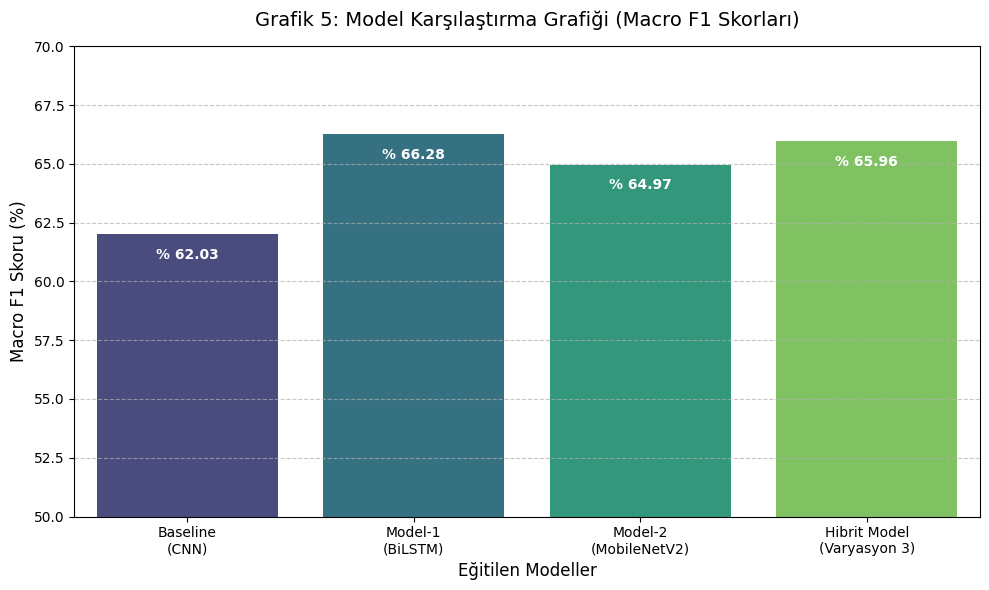

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Grafik 5: Modellerin Performans Karşılaştırması ===")

# Elde ettiğimiz metrikleri (Macro F1) listelere alıyoruz
models = ['Baseline\n(CNN)', 'Model-1\n(BiLSTM)', 'Model-2\n(MobileNetV2)', 'Hibrit Model\n(Varyasyon 3)']
f1_scores = [62.03, 66.28, 64.97, 65.96]

plt.figure(figsize=(10, 6))
# Seaborn uyarısını engellemek için hue eklendi
ax = sns.barplot(x=models, y=f1_scores, palette='viridis', hue=models, legend=False)

plt.title('Grafik 5: Model Karşılaştırma Grafiği (Macro F1 Skorları)', fontsize=14, pad=15)
plt.ylabel('Macro F1 Skoru (%)', fontsize=12)
plt.xlabel('Eğitilen Modeller', fontsize=12)

# Modeller arasındaki farkların net görünmesi için Y eksenini 50'den başlatıyoruz
plt.ylim(50, 70)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Barların üzerine değerleri yazdırma
for p in ax.patches:
    ax.annotate(f'% {p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, -15), # Yazıyı barın hafif içine alıyoruz
                textcoords='offset points',
                color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 12.2. Sınırlılıklar (Limitations)
Projeden elde edilen sonuçlar umut verici olsa da belirli teknik sınırlar çerçevesinde değerlendirilmelidir:
* **Veri Seti Sınırlılığı:** Sınıflar arası şiddetli bir dengesizlik mevcuttur. "Apparel" sınıfı veri setini domine ederken, "Free Items" veya "Sporting Goods" gibi sınıflar yok denecek kadar azdır. Ayrıca bazı etiketlerin ürünün fiziksel yapısı yerine ticari kampanyaları yansıtması veri gürültüsü yaratmıştır.
* **Model ve Hesaplama Maliyeti:** Hibrit model, tekil modellere (özellikle BiLSTM) kıyasla çok daha fazla parametreye (~2.75 Milyon) sahiptir. Bu durum eğitim süresini ve çıkarım (inference) maliyetini artırmaktadır.
* **Genelleme Sınırı:** Model, yeterince örnek göremediği azınlık sınıflarında neredeyse hiç ayrım yapamamış, Macro F1 skorunun belirli bir bandın üzerine çıkması engellenmiştir.

### 12.3. Gerçek Dünya Dağıtımı (Deployment) İçin Ek Testler
Bu model canlı bir e-ticaret sistemine entegre edilecek olsaydı, devreye alınmadan önce şu testlerin yapılması gerekirdi:
1. **OOD (Out-of-Distribution) Testleri:** Modelin eğitim setindekilerden tamamen farklı arka planlara sahip, kullanıcılar tarafından düşük çözünürlükle ve kötü ışıkta çekilmiş fotoğraflara vereceği tepkiler ölçülmelidir.
2. **Gecikme (Latency) ve Yük Testleri:** E-ticaret sitelerinde milisaniyeler önemlidir. Çok modlu yapının, saniyede binlerce isteğin (request) geldiği bir senaryoda CPU/GPU üzerindeki çıkarım (inference) hızı ölçülmelidir.
3. **A/B Testi:** Model canlıya alındığında, ürün kategorizasyonunu insanların yaptığı geleneksel sistem ile yapay zekanın yaptığı sistem arasındaki kullanıcı tıklama/dönüşüm oranları karşılaştırılmalıdır.

### 12.4. Gelecek İyileştirme Önerileri (Future Work)
Mevcut mimariyi ve başarı oranını bir adım öteye taşımak için şu üç somut iyileştirme uygulanabilir:
1. **Dinamik Odaklanma (Attention Mechanism):** İki farklı vektörü basitçe uç uca eklemek (Concatenation) yerine, Cross-Attention (Çapraz Dikkat) katmanları kullanılabilir. Böylece model, örneğin metin anlamsız olduğunda tüm ağırlığı görüntüye, görüntü bulanık olduğunda ise tüm ağırlığı metne verecek dinamik bir denge kurabilir.
2. **Kayıp Fonksiyonu Optimizasyonu (Focal Loss):** Sınıf dengesizliğini çözmek için basit 'class_weights' (sınıf ağırlıkları) yerine, modelin yanlış tahmin ettiği zorlu örnekleri merkeze alan **Focal Loss** kullanılarak azınlık sınıflarındaki performans artırılabilir.
3. **Veri Seti Temizliği ve Veri Çoğaltma:** Veri seti "Bedava Ürün" gibi mantıksal olmayan etiketlerden arındırılmalı ve azınlık sınıfları için gelişmiş artırma teknikleri (Örn: Görsel için MixUp, metin için NLP Data Augmentation/Paraphrasing) kullanılarak veriler dengelenmelidir.